# EDA Cartera Sintetica de Seguros (Automotor)

Notebook completo para analizar `polizas_sinteticas.csv` y `siniestros_sinteticos.csv` con estilo `ggplot`.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')
sns.set_context('notebook')
pd.set_option('display.max_columns', 120)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

import warnings
warnings.filterwarnings("ignore")


In [2]:
base_dir = Path.cwd()
output_dir = base_dir / 'output'

polizas_path = output_dir / 'polizas_sinteticas.csv'
siniestros_path = output_dir / 'siniestros_sinteticos.csv'

if not polizas_path.exists() or not siniestros_path.exists():
    raise FileNotFoundError('No se encontraron CSV en ./output. Ejecuta primero: uv run python main.py')

df_polizas = pd.read_csv(polizas_path, parse_dates=['fecha_inicio_vigencia', 'fecha_fin_vigencia', 'fecha_cancelacion'])
df_siniestros = pd.read_csv(siniestros_path, parse_dates=['fecha_siniestro', 'fecha_denuncia', 'fecha_inicio_juicio'])

# Ensure boolean columns
for _bcol in ['cancelada', 'es_flota', 'renovada']:
    if _bcol in df_polizas.columns:
        df_polizas[_bcol] = df_polizas[_bcol].fillna(False).astype(bool)

print('Polizas:', df_polizas.shape)
print('Siniestros:', df_siniestros.shape)


Polizas: (100000, 36)
Siniestros: (16757, 24)


## 1) EDA de Polizas

Esta sección explora la tabla de **pólizas sintéticas**. Se muestran estadísticas descriptivas, porcentaje de valores faltantes y las distribuciones de las variables más relevantes: plan de cobertura, provincia, zona de riesgo, edad del asegurado, tipo y uso del vehículo, y canal de venta. También se incluye la distribución de las primas por canal. El objetivo es entender la composición de la cartera antes de analizar la siniestralidad.

In [3]:
display(df_polizas.head())
display(df_polizas.describe(include='all').transpose())
display((df_polizas.isna().mean()*100).sort_values(ascending=False).head(20).to_frame('pct_faltante'))


,id_poliza,fecha_inicio_vigencia,fecha_fin_vigencia,numero_poliza,ramo,plan_cobertura,provincia,localidad,barrio,zona_riesgo,edad_asegurado,genero_asegurado,estado_civil,ocupacion,canal_venta,codigo_productor,tiempo_productor_cia_meses,codigo_organizador,comision_pactada,marca_vehiculo,modelo_vehiculo,tipo_vehiculo,anio_vehiculo,suma_asegurada,tipo_uso,es_flota,categoria_cobertura,prima,premio,meses_en_mora,renovada,id_cliente,numero_renovacion,cancelada,fecha_cancelacion,motivo_cancelacion
0,1,2024-08-15,2025-08-15,AUT-2024-000001,Automotor,Responsabilidad Civil,San Juan,Chimbas,NaN,Baja,50,F,Soltero,Empleado,Productor,PROD-0001,237,ORG-45,0.15,Toyota,Hilux,Camioneta,2014,"45,000,000.00",Particular,False,Solo RC,"2,750,398.08","3,190,236.71",1,True,48144,2,False,NaT,NaN
1,2,2024-07-29,2025-07-29,AUT-2024-000002,Motovehiculos,Terceros Completo,CABA,San Nicolás,Monserrat,Alta,38,F,Soltero,Profesional,Productor,PROD-0061,213,ORG-14,0.21,Honda,XRE300,Moto,2021,"4,629,081.27",Comercial,False,RC + Casco Básico,"280,041.29","333,030.78",0,False,14136,0,False,NaT,NaN
2,3,2024-07-09,2025-07-09,AUT-2024-000003,Automotor,Todo Riesgo,CABA,Villa Pueyrredón,Constitución,Alta,45,F,Casado,Empleado,Organizador,PROD-0003,218,ORG-45,0.17,Honda,Civic,Auto,2023,"22,390,336.94",Comercial,False,RC + Casco Total,"2,810,728.56","3,476,852.67",0,True,15496,3,False,NaT,NaN
3,4,2024-10-15,2025-10-15,AUT-2024-000004,Automotor,Terceros Completo,CABA,Parque Avellaneda,Recoleta,Alta,44,M,Casado,Empleado,Productor,PROD-0006,236,ORG-26,0.12,Suzuki,Swift,Auto,2023,"29,166,499.13",Particular,False,RC + Casco Básico,"1,477,241.31","1,823,065.37",1,True,26436,2,False,NaT,NaN
4,5,2022-09-30,2023-09-30,AUT-2022-000005,Automotor,Terceros Completo,Mendoza,Coquimbito,Tapiales,Media,31,F,Divorciado,Independiente,Broker,PROD-0001,240,ORG-31,0.10,Volkswagen,Polo,Auto,2020,"19,125,183.89",Particular,False,RC + Casco Básico,"1,156,539.63","1,432,713.80",1,True,17558,2,False,NaT,NaN


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
id_poliza,"100,000.00",NaN,NaN,NaN,"50,000.50",1.00,"25,000.75","50,000.50","75,000.25","100,000.00","28,867.66"
fecha_inicio_vigencia,100000,NaN,NaN,NaN,2023-01-04 10:11:33.216000,2021-01-01 00:00:00,2022-01-02 00:00:00,2022-12-29 00:00:00,2023-12-30 00:00:00,2024-12-31 00:00:00,NaN
fecha_fin_vigencia,100000,NaN,NaN,NaN,2024-01-04 10:11:33.216000,2022-01-01 00:00:00,2023-01-02 00:00:00,2023-12-29 00:00:00,2024-12-29 00:00:00,2025-12-31 00:00:00,NaN
numero_poliza,100000,100000,AUT-2024-000001,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ramo,100000,2,Automotor,87932,NaN,NaN,NaN,NaN,NaN,NaN,NaN
plan_cobertura,100000,3,Responsabilidad Civil,40180,NaN,NaN,NaN,NaN,NaN,NaN,NaN
provincia,100000,20,Buenos Aires,35992,NaN,NaN,NaN,NaN,NaN,NaN,NaN
localidad,100000,399,San Nicolás,805,NaN,NaN,NaN,NaN,NaN,NaN,NaN
barrio,48032,110,Carapachay,517,NaN,NaN,NaN,NaN,NaN,NaN,NaN
zona_riesgo,100000,3,Media,43754,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,pct_faltante
motivo_cancelacion,91.79
fecha_cancelacion,91.79
barrio,51.97
codigo_organizador,14.72
categoria_cobertura,0.00
tipo_vehiculo,0.00
anio_vehiculo,0.00
suma_asegurada,0.00
tipo_uso,0.00
es_flota,0.00


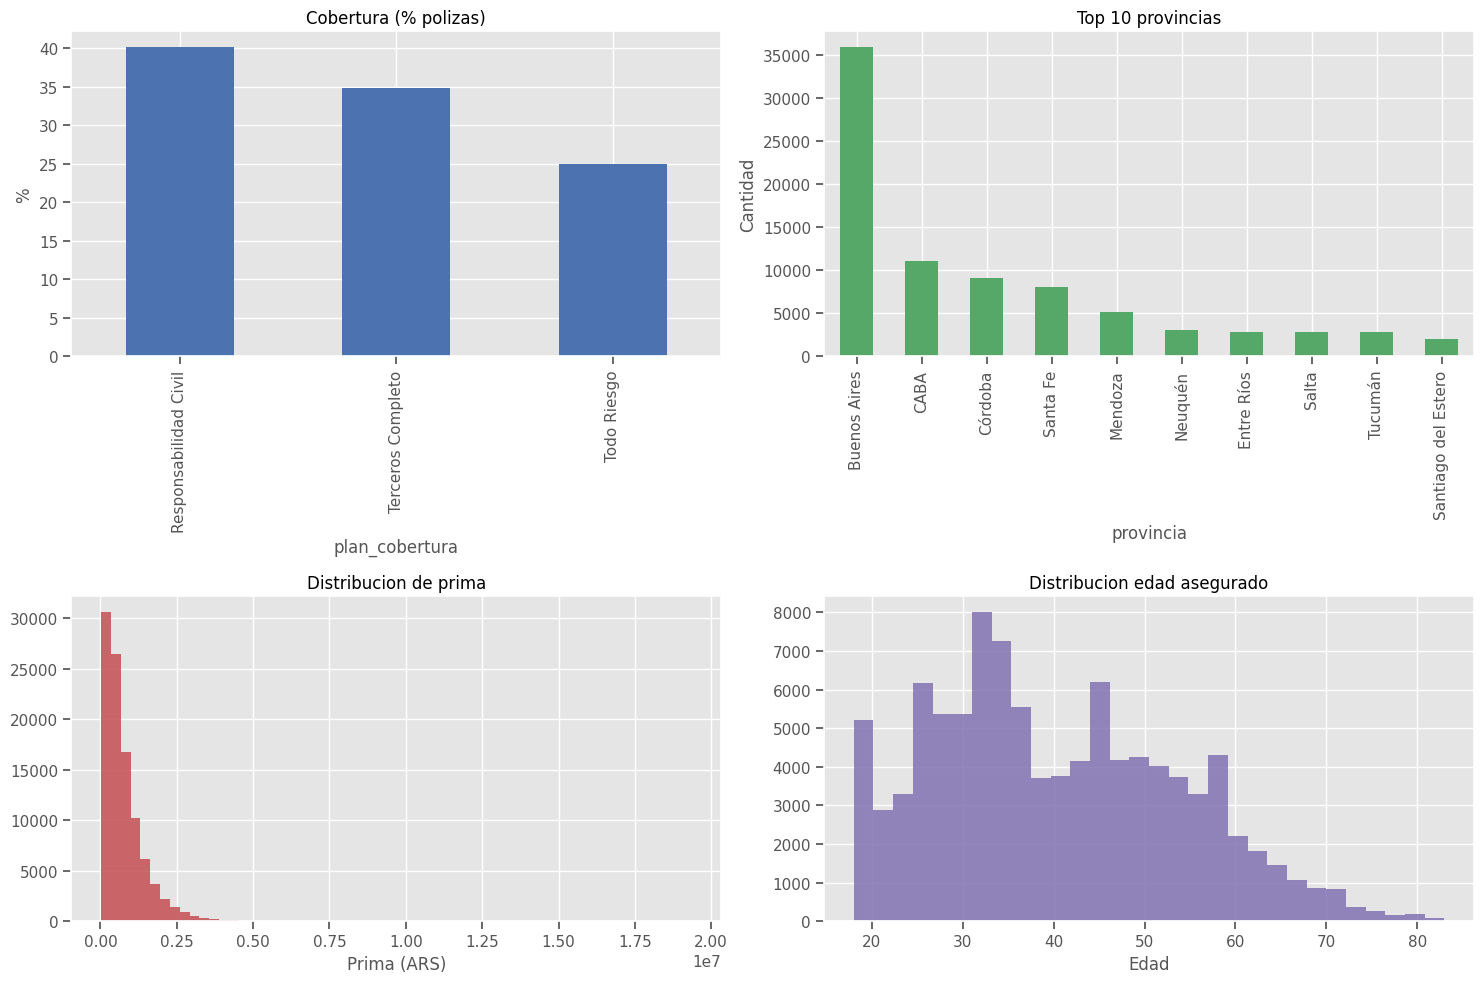

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

(df_polizas['plan_cobertura'].value_counts(normalize=True).mul(100).sort_values(ascending=False)
 .plot(kind='bar', ax=axes[0,0], color='#4c72b0', title='Cobertura (% polizas)'))
axes[0,0].set_ylabel('%')

(df_polizas['provincia'].value_counts().head(10)
 .plot(kind='bar', ax=axes[0,1], color='#55a868', title='Top 10 provincias'))
axes[0,1].set_ylabel('Cantidad')

axes[1,0].hist(df_polizas['prima'], bins=60, color='#c44e52', alpha=0.85)
axes[1,0].set_title('Distribucion de prima')
axes[1,0].set_xlabel('Prima (ARS)')

axes[1,1].hist(df_polizas['edad_asegurado'], bins=30, color='#8172b3', alpha=0.85)
axes[1,1].set_title('Distribucion edad asegurado')
axes[1,1].set_xlabel('Edad')

plt.tight_layout()
plt.show()


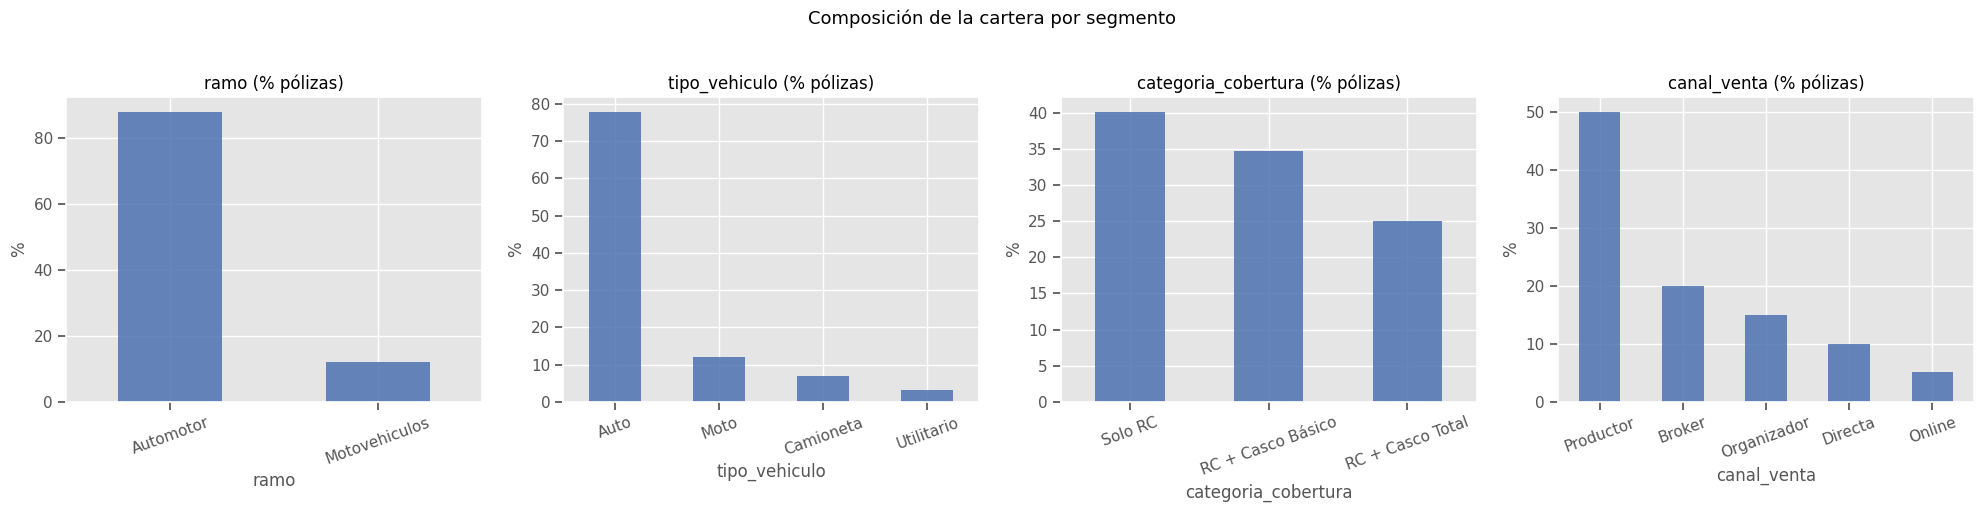

In [5]:

# Nuevas dimensiones de cartera: ramo, tipo_vehiculo, canal y tipo_uso
cols_nuevos = ['ramo', 'tipo_vehiculo', 'categoria_cobertura', 'canal_venta']
cols_disponibles = [c for c in cols_nuevos if c in df_polizas.columns]

if cols_disponibles:
    fig, axes = plt.subplots(1, len(cols_disponibles), figsize=(5 * len(cols_disponibles), 5))
    if len(cols_disponibles) == 1:
        axes = [axes]
    for ax, col in zip(axes, cols_disponibles):
        (df_polizas[col].value_counts(normalize=True).mul(100)
         .sort_values(ascending=False)
         .plot(kind='bar', ax=ax, color='#4c72b0', alpha=0.85))
        ax.set_title(f'{col} (% pólizas)')
        ax.set_ylabel('%')
        ax.tick_params(axis='x', rotation=20)
    plt.suptitle('Composición de la cartera por segmento', fontsize=13, y=1.02)
    plt.tight_layout()
    plt.show()
else:
    print('Regenerar output con el nuevo main.py para ver ramo, tipo_vehiculo y categoria_cobertura.')


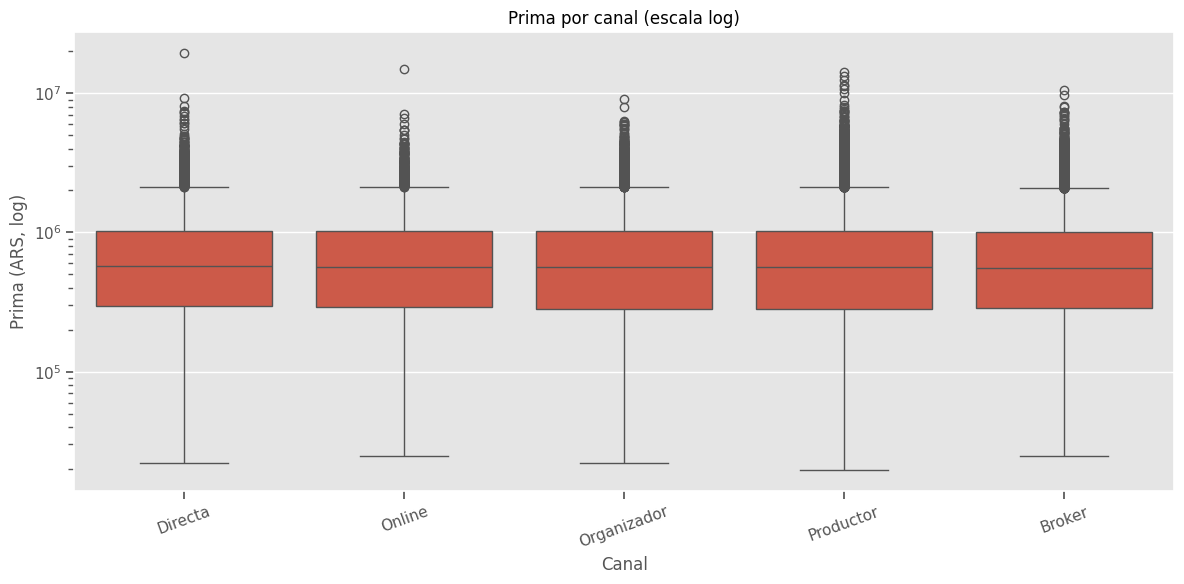

In [6]:
plt.figure(figsize=(12,6))
orden = df_polizas.groupby('canal_venta')['prima'].median().sort_values(ascending=False).index
sns.boxplot(data=df_polizas, x='canal_venta', y='prima', order=orden)
plt.yscale('log')
plt.title('Prima por canal (escala log)')
plt.xlabel('Canal')
plt.ylabel('Prima (ARS, log)')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


## 2) EDA de Siniestros

Esta sección explora la tabla de **siniestros sintéticos**. Se revisan estadísticas básicas, valores faltantes y la distribución del **lag de denuncia** (días entre la fecha del siniestro y su reporte a la aseguradora). También se analiza la distribución por tipo de daño (`tipo_danio`) y los indicadores legales: porcentaje de siniestros en mediación, en juicio y con sentencia. Un lag elevado puede indicar problemas de reserva; un alto porcentaje en juicio señala exposición legal.

In [7]:
display(df_siniestros.head())
display(df_siniestros.describe(include='all').transpose())
display((df_siniestros.isna().mean()*100).sort_values(ascending=False).head(20).to_frame('pct_faltante'))


,id_siniestro,numero_siniestro,id_poliza,ramo,fecha_siniestro,fecha_denuncia,fecha_inicio_juicio,tipo_danio,monto_reclamado,monto_reservado,monto_pagado,estado_siniestro,motivo_rechazo,gasto_liquidacion,cobertura_casco,cobertura_rc,categoria_siniestro,en_mediacion,en_juicio,con_sentencia,terceros_involucrados,conductor_es_asegurado,bien_recuperado,ubicacion_siniestro
0,1,SIN-2023-000001,10,Automotor,2023-05-28,2023-05-30,NaT,Granizo,"559,435.82","507,703.69",0.00,Rechazado,Falta de cobertura,"26,058.06",False,False,Mixto,True,False,False,False,True,NaN,Buenos Aires
1,2,SIN-2023-000002,14,Automotor,2023-10-13,2023-10-17,NaT,Choque,"2,744,433.67","3,459,620.94","2,008,999.85",Cerrado,NaN,"133,753.89",True,False,Casco,False,False,False,False,True,NaN,Santa Fe
2,3,SIN-2022-000003,17,Motovehiculos,2022-12-14,2022-12-16,NaT,Otros,"23,597.75","20,219.24","18,298.68",Cerrado,NaN,"48,841.41",False,False,Mixto,False,False,False,False,True,NaN,CABA
3,4,SIN-2023-000004,17,Motovehiculos,2023-06-29,2023-07-01,NaT,Daño a terceros,"1,782,210.07","2,053,012.31","1,568,353.13",Cerrado,NaN,"131,579.83",False,True,RC,True,False,False,True,True,NaN,CABA
4,5,SIN-2023-000005,18,Automotor,2023-03-25,2023-03-28,NaT,Robo total,"20,169,174.58","19,850,255.06","15,843,968.21",Cerrado,NaN,"1,005,714.50",False,False,Mixto,False,False,False,False,False,False,Buenos Aires


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
id_siniestro,"16,757.00",NaN,NaN,NaN,"8,379.00",1.00,"4,190.00","8,379.00","12,568.00","16,757.00","4,837.47"
numero_siniestro,16757,16757,SIN-2023-000001,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
id_poliza,"16,757.00",NaN,NaN,NaN,"50,143.55",10.00,"25,293.00","50,071.00","74,969.00","99,998.00","28,793.94"
ramo,16757,2,Automotor,13540,NaN,NaN,NaN,NaN,NaN,NaN,NaN
fecha_siniestro,16757,NaN,NaN,NaN,2023-07-03 15:29:38.194187,2021-01-08 00:00:00,2022-07-12 00:00:00,2023-07-05 00:00:00,2024-06-29 00:00:00,2025-12-22 00:00:00,NaN
fecha_denuncia,16757,NaN,NaN,NaN,2023-07-08 14:29:23.800203,2021-01-11 00:00:00,2022-07-16 00:00:00,2023-07-09 00:00:00,2024-07-04 00:00:00,2025-12-27 00:00:00,NaN
fecha_inicio_juicio,514,NaN,NaN,NaN,2023-12-27 17:22:10.739299,2021-03-27 00:00:00,2022-12-29 00:00:00,2024-01-18 00:00:00,2024-12-10 12:00:00,2029-06-30 00:00:00,NaN
tipo_danio,16757,7,Choque,6815,NaN,NaN,NaN,NaN,NaN,NaN,NaN
monto_reclamado,"16,757.00",NaN,NaN,NaN,"3,565,234.12","10,567.76","541,507.47","1,428,518.16","3,724,344.15","397,984,961.77","7,810,072.56"
monto_reservado,"16,757.00",NaN,NaN,NaN,"3,823,171.60","11,866.64","576,041.29","1,530,827.38","4,014,588.03","382,463,119.48","8,189,142.90"


,pct_faltante
fecha_inicio_juicio,96.93
motivo_rechazo,92.55
bien_recuperado,84.11
gasto_liquidacion,0.00
conductor_es_asegurado,0.00
terceros_involucrados,0.00
con_sentencia,0.00
en_juicio,0.00
en_mediacion,0.00
categoria_siniestro,0.00


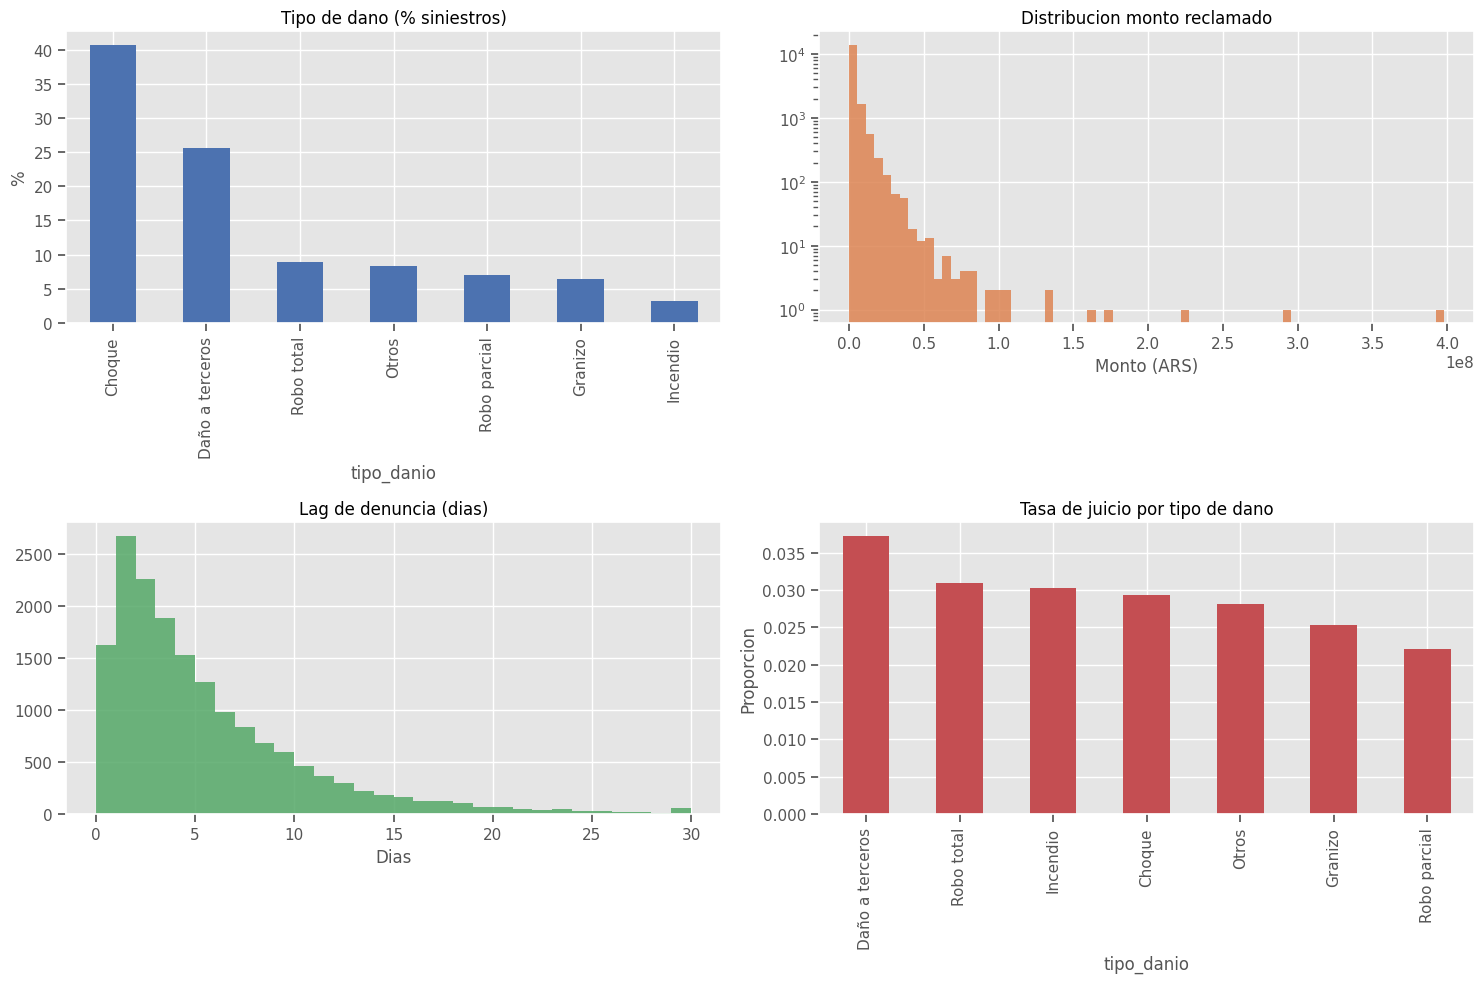

In [8]:
df_siniestros['lag_denuncia_dias'] = (df_siniestros['fecha_denuncia'] - df_siniestros['fecha_siniestro']).dt.days

fig, axes = plt.subplots(2, 2, figsize=(15,10))

(df_siniestros['tipo_danio'].value_counts(normalize=True).mul(100).sort_values(ascending=False)
 .plot(kind='bar', ax=axes[0,0], color='#4c72b0', title='Tipo de dano (% siniestros)'))
axes[0,0].set_ylabel('%')

axes[0,1].hist(df_siniestros['monto_reclamado'], bins=70, color='#dd8452', alpha=0.85)
axes[0,1].set_title('Distribucion monto reclamado')
axes[0,1].set_xlabel('Monto (ARS)')
axes[0,1].set_yscale('log')

axes[1,0].hist(df_siniestros['lag_denuncia_dias'].dropna(), bins=30, color='#55a868', alpha=0.85)
axes[1,0].set_title('Lag de denuncia (dias)')
axes[1,0].set_xlabel('Dias')

juicio_rate = df_siniestros.groupby('tipo_danio')['en_juicio'].mean().sort_values(ascending=False)
juicio_rate.plot(kind='bar', ax=axes[1,1], color='#c44e52', title='Tasa de juicio por tipo de dano')
axes[1,1].set_ylabel('Proporcion')

plt.tight_layout()
plt.show()


## 3) Loss Ratio por Grupos

El **loss ratio (LR)** es la métrica central de rentabilidad: `LR = siniestros_pagados / prima`. Un LR > 1 indica que el segmento pierde dinero. Aquí se calcula el LR por **provincia** (top 10), **plan de cobertura**, **zona de riesgo** y **grupo de edad**. Se espera que zonas de alto riesgo (Alta) tengan LR más elevado, que "Todo Riesgo" concentre más siniestralidad, y que conductores jóvenes (< 25) muestren peor resultado técnico.

In [9]:
siniestros_poliza = (df_siniestros.groupby('id_poliza', as_index=False)
                    .agg(
                        siniestros_incurridos=('monto_reclamado', 'sum'),
                        pagos_totales=('monto_pagado', 'sum'),
                        gastos_totales=('gasto_liquidacion', 'sum'),
                        reservas_totales=('monto_reservado', 'sum'),
                        n_rechazados=('estado_siniestro', lambda x: (x == 'Rechazado').sum()),
                        n_abiertos=('estado_siniestro', lambda x: (x == 'Abierto').sum()),
                    ))

df_lr = df_polizas.merge(siniestros_poliza, on='id_poliza', how='left')
for _fc in ['siniestros_incurridos','pagos_totales','gastos_totales','reservas_totales','n_rechazados','n_abiertos']:
    df_lr[_fc] = df_lr[_fc].fillna(0)
df_lr['loss_ratio_poliza'] = np.where(df_lr['prima'] > 0, df_lr['siniestros_incurridos']/df_lr['prima'], np.nan)
df_lr['loss_ratio_pagado_poliza'] = np.where(df_lr['prima'] > 0, df_lr['pagos_totales']/df_lr['prima'], np.nan)

lr_global = df_lr['siniestros_incurridos'].sum() / df_lr['prima'].sum()
lr_pagado_global = df_lr['pagos_totales'].sum() / df_lr['prima'].sum()
expense_global = df_lr['gastos_totales'].sum() / df_lr['prima'].sum()
combined_global = lr_pagado_global + expense_global

print(f'Loss ratio global (reclamado): {lr_global:.4f} ({lr_global*100:.2f}%)')
print(f'Loss ratio global (pagado):    {lr_pagado_global:.4f} ({lr_pagado_global*100:.2f}%)')
print(f'Expense ratio:                 {expense_global:.4f} ({expense_global*100:.2f}%)')
print(f'Combined ratio:                {combined_global:.4f} ({combined_global*100:.2f}%)')


Loss ratio global (reclamado): 0.7846 (78.46%)
Loss ratio global (pagado):    0.4920 (49.20%)
Expense ratio:                 0.0468 (4.68%)
Combined ratio:                0.5388 (53.88%)


In [10]:
def resumen_loss_ratio(df, grupo):
    t = (df.groupby(grupo, as_index=False)
         .agg(polizas=('id_poliza','count'), prima_total=('prima','sum'), siniestros_total=('siniestros_incurridos','sum')))
    t['loss_ratio'] = t['siniestros_total'] / t['prima_total']
    return t.sort_values('loss_ratio', ascending=False)

lr_provincia = resumen_loss_ratio(df_lr, 'provincia')
lr_canal = resumen_loss_ratio(df_lr, 'canal_venta')
lr_cobertura = resumen_loss_ratio(df_lr, 'plan_cobertura')
lr_zona = resumen_loss_ratio(df_lr, 'zona_riesgo')

display(lr_provincia.head(12))
display(lr_canal)
display(lr_cobertura)
display(lr_zona)


,provincia,polizas,prima_total,siniestros_total,loss_ratio
1,CABA,11107,"9,483,442,909.84","10,432,701,241.01",1.10
0,Buenos Aires,35992,"29,025,906,229.23","26,781,228,732.99",0.92
10,Mendoza,5137,"3,866,328,552.33","3,076,482,468.83",0.80
17,Santa Fe,8052,"6,100,003,625.91","4,477,817,659.97",0.73
5,Córdoba,9144,"7,054,810,263.88","5,070,151,909.73",0.72
14,Salta,2898,"2,001,804,224.54","1,155,775,388.37",0.58
18,Santiago del Estero,2040,"1,309,142,168.70","718,817,049.41",0.55
11,Misiones,2011,"1,360,735,974.63","686,850,804.41",0.50
19,Tucumán,2878,"1,934,588,645.51","969,265,813.91",0.50
7,Formosa,1002,"676,505,128.00","338,533,757.94",0.50


,canal_venta,polizas,prima_total,siniestros_total,loss_ratio
0,Broker,19942,"15,055,019,826.20","12,709,373,800.62",0.84
2,Online,5150,"3,944,225,731.80","3,161,730,951.08",0.80
4,Productor,50013,"38,175,078,194.95","29,315,489,451.43",0.77
1,Directa,9897,"7,607,286,769.96","5,839,554,298.02",0.77
3,Organizador,14998,"11,357,627,696.35","8,716,479,610.79",0.77


,plan_cobertura,polizas,prima_total,siniestros_total,loss_ratio
0,Responsabilidad Civil,40180,"22,032,476,147.66","22,707,165,914.21",1.03
1,Terceros Completo,34792,"27,817,250,162.71","19,584,377,495.81",0.70
2,Todo Riesgo,25028,"26,289,511,908.89","17,451,084,701.92",0.66


,zona_riesgo,polizas,prima_total,siniestros_total,loss_ratio
0,Alta,25678,"22,024,644,540.05","25,330,557,240.15",1.15
2,Media,43754,"33,505,847,041.14","24,507,824,772.38",0.73
1,Baja,30568,"20,608,746,638.07","9,904,246,099.41",0.48


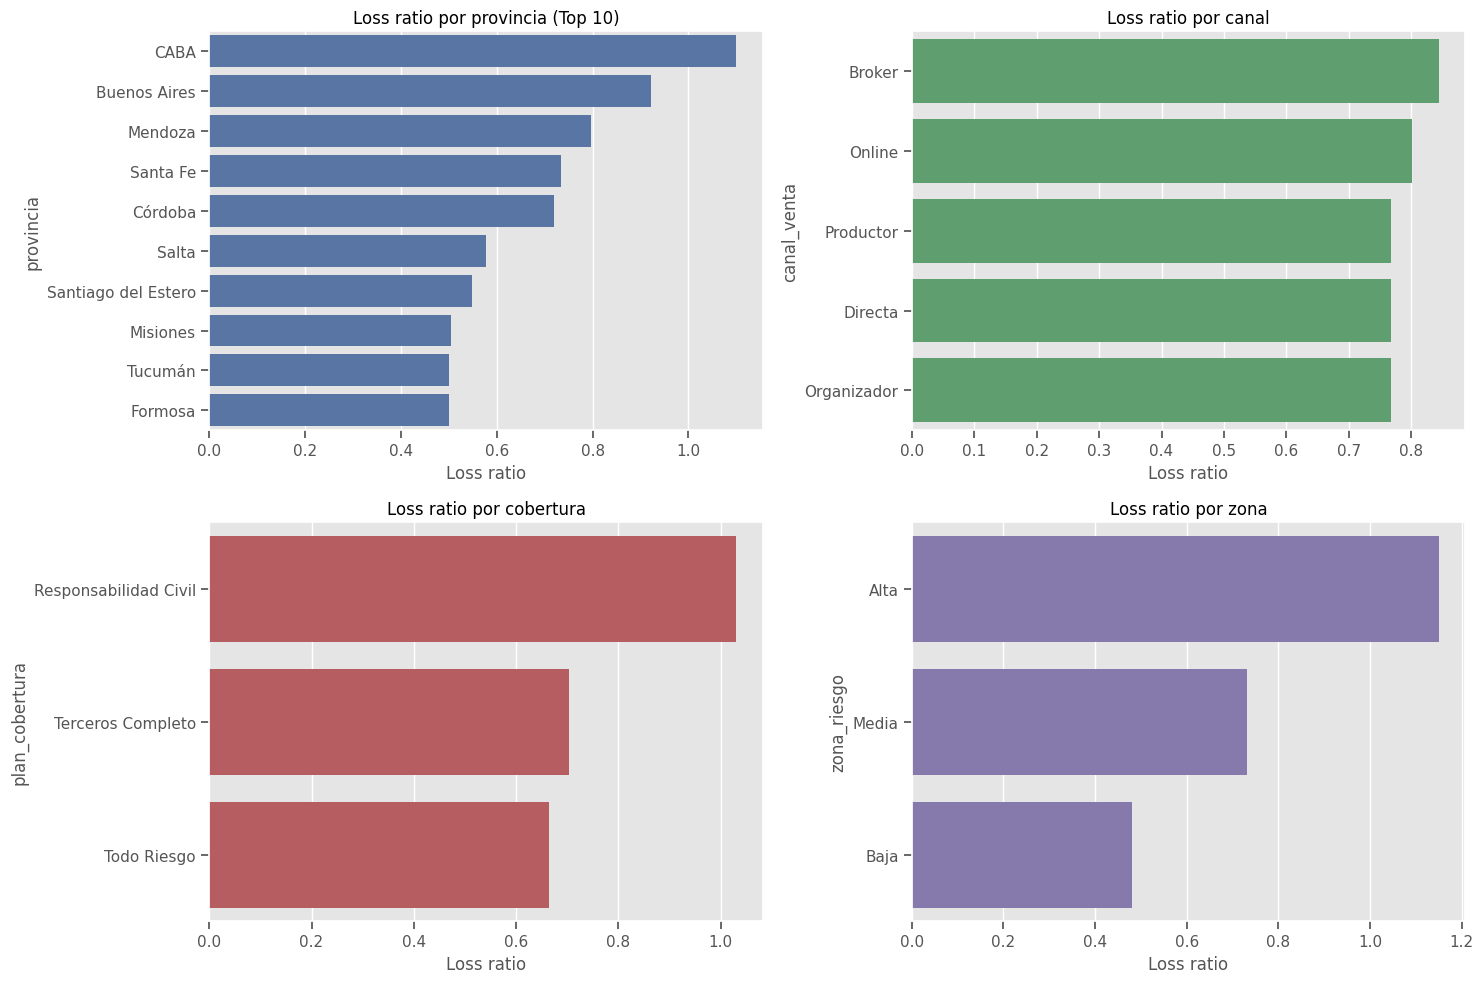

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(15,10))

sns.barplot(data=lr_provincia.head(10), x='loss_ratio', y='provincia', ax=axes[0,0], color='#4c72b0')
axes[0,0].set_title('Loss ratio por provincia (Top 10)')

sns.barplot(data=lr_canal, x='loss_ratio', y='canal_venta', ax=axes[0,1], color='#55a868')
axes[0,1].set_title('Loss ratio por canal')

sns.barplot(data=lr_cobertura, x='loss_ratio', y='plan_cobertura', ax=axes[1,0], color='#c44e52')
axes[1,0].set_title('Loss ratio por cobertura')

sns.barplot(data=lr_zona, x='loss_ratio', y='zona_riesgo', ax=axes[1,1], color='#8172b3')
axes[1,1].set_title('Loss ratio por zona')

for ax in axes.flat:
    ax.set_xlabel('Loss ratio')

plt.tight_layout()
plt.show()


## 4) Analisis Profundo por Grupos

Análisis más detallado que combina **antigüedad del vehículo** (grupos: hasta 2010, 2011-2015, 2016-2020, 2021+) con zona, cobertura y edad. También incluye el **ranking de productores**: los 20 productores con mayor volumen de primas y los 20 con mayor LR (posibles señales de selección adversa o fraude). Los vehículos muy viejos (> 15 años) tienden a tener peor relación costo-reparación; los productores con LR extremo merecen seguimiento.

In [12]:
df_lr['anio_vehiculo_grupo'] = pd.cut(
    df_lr['anio_vehiculo'],
    bins=[2004, 2010, 2015, 2020, 2024],
    labels=['2005-2010', '2011-2015', '2016-2020', '2021-2024']
)

df_lr['antiguedad_vehiculo'] = 2024 - df_lr['anio_vehiculo']
df_lr['antiguedad_vehiculo_grupo'] = pd.cut(
    df_lr['antiguedad_vehiculo'],
    bins=[-1, 2, 7, 15, 50],
    labels=['0-2', '3-7', '8-15', '16+']
)

df_lr['edad_grupo'] = pd.cut(
    df_lr['edad_asegurado'],
    bins=[17, 24, 34, 44, 54, 64, 100],
    labels=['18-24', '25-34', '35-44', '45-54', '55-64', '65+']
)

conteo_siniestros = df_siniestros.groupby('id_poliza').size().rename('cantidad_siniestros')
df_lr = df_lr.merge(conteo_siniestros, on='id_poliza', how='left')
df_lr['cantidad_siniestros'] = df_lr['cantidad_siniestros'].fillna(0).astype(int)
df_lr['tuvo_siniestro'] = df_lr['cantidad_siniestros'] > 0
df_lr['severidad_promedio_poliza'] = np.where(
    df_lr['cantidad_siniestros'] > 0,
    df_lr['siniestros_incurridos'] / df_lr['cantidad_siniestros'],
    np.nan
)


In [13]:
def resumen_segmento(df, grupo):
    base = (
        df.groupby(grupo, as_index=False)
        .agg(
            polizas=('id_poliza', 'count'),
            prima_total=('prima', 'sum'),
            siniestros_total=('siniestros_incurridos', 'sum'),
            frecuencia=('tuvo_siniestro', 'mean'),
            siniestros_por_poliza=('cantidad_siniestros', 'mean'),
            severidad_promedio=('severidad_promedio_poliza', 'mean')
        )
    )
    base['loss_ratio'] = base['siniestros_total'] / base['prima_total']
    return base.sort_values('loss_ratio', ascending=False)

seg_edad = resumen_segmento(df_lr, 'edad_grupo')
seg_productor = resumen_segmento(df_lr, 'codigo_productor')
seg_anio = resumen_segmento(df_lr, 'anio_vehiculo_grupo')
seg_antig = resumen_segmento(df_lr, 'antiguedad_vehiculo_grupo')
seg_tipo = resumen_segmento(df_lr, 'tipo_uso')

display(seg_edad)
display(seg_anio)
display(seg_antig)
display(seg_tipo)


,edad_grupo,polizas,prima_total,siniestros_total,frecuencia,siniestros_por_poliza,severidad_promedio,loss_ratio
1,25-34,27549,"20,921,649,399.66","18,037,959,476.64",0.17,0.18,"3,626,754.21",0.86
3,45-54,20315,"14,989,598,372.46","12,301,346,269.18",0.15,0.16,"3,708,471.17",0.82
2,35-44,23849,"17,499,140,450.82","14,073,035,098.07",0.15,0.16,"3,626,894.79",0.80
0,18-24,11373,"9,715,010,781.23","7,016,000,135.52",0.16,0.17,"3,543,212.44",0.72
4,55-64,12403,"9,402,652,061.65","6,279,633,250.74",0.14,0.15,"3,333,159.19",0.67
5,65+,4511,"3,611,187,153.44","2,034,653,881.79",0.13,0.14,"3,226,893.41",0.56


,anio_vehiculo_grupo,polizas,prima_total,siniestros_total,frecuencia,siniestros_por_poliza,severidad_promedio,loss_ratio
0,2005-2010,9782,"5,273,771,291.00","5,349,705,074.40",0.15,0.17,"3,345,223.95",1.01
1,2011-2015,16382,"9,644,779,836.84","9,639,551,722.57",0.15,0.17,"3,596,471.73",1.00
2,2016-2020,30832,"21,663,441,558.62","18,879,101,199.77",0.15,0.17,"3,666,687.76",0.87
3,2021-2024,43004,"39,557,245,532.80","25,874,270,115.20",0.15,0.17,"3,574,752.02",0.65


,antiguedad_vehiculo_grupo,polizas,prima_total,siniestros_total,frecuencia,siniestros_por_poliza,severidad_promedio,loss_ratio
2,8-15,25391,"15,128,506,808.10","15,299,239,846.32",0.15,0.17,"3,669,606.71",1.01
3,16+,5577,"3,003,635,449.20","2,915,708,338.91",0.15,0.17,"3,120,509.99",0.97
1,3-7,34912,"25,716,849,867.10","20,380,086,505.55",0.15,0.16,"3,558,013.81",0.79
0,0-2,34120,"32,290,246,094.86","21,147,593,421.16",0.16,0.17,"3,622,256.82",0.65


,tipo_uso,polizas,prima_total,siniestros_total,frecuencia,siniestros_por_poliza,severidad_promedio,loss_ratio
2,Profesional,4910,"3,756,035,103.12","3,413,002,591.69",0.15,0.17,"3,986,617.93",0.91
1,Particular,78354,"59,868,070,329.33","46,607,707,714.56",0.15,0.17,"3,583,807.34",0.78
0,Comercial,16736,"12,515,132,786.81","9,721,917,805.69",0.15,0.17,"3,467,728.02",0.78


In [14]:
top_productores_vol = seg_productor.sort_values('polizas', ascending=False).head(20)
top_productores_lr = seg_productor[seg_productor['polizas'] >= 40].sort_values('loss_ratio', ascending=False).head(20)

print('Top 20 productores por volumen:')
display(top_productores_vol[['codigo_productor','polizas','frecuencia','loss_ratio']])

print('Top 20 productores por loss ratio (min 40 polizas):')
display(top_productores_lr[['codigo_productor','polizas','frecuencia','loss_ratio','severidad_promedio']])


Top 20 productores por volumen:


,codigo_productor,polizas,frecuencia,loss_ratio
0,PROD-0001,20380,0.15,0.78
1,PROD-0002,9216,0.15,0.76
2,PROD-0003,5766,0.15,0.73
3,PROD-0004,4097,0.14,0.71
4,PROD-0005,3187,0.15,0.90
5,PROD-0006,2807,0.16,1.06
6,PROD-0007,2222,0.16,0.92
7,PROD-0008,1796,0.16,0.73
8,PROD-0009,1671,0.16,0.74
9,PROD-0010,1330,0.15,0.66


Top 20 productores por loss ratio (min 40 polizas):


,codigo_productor,polizas,frecuencia,loss_ratio,severidad_promedio
173,PROD-0174,63,0.22,2.89,"6,189,167.44"
177,PROD-0178,85,0.22,2.43,"8,872,713.00"
142,PROD-0143,69,0.23,2.41,"6,950,314.12"
299,PROD-0300,43,0.19,2.40,"7,988,221.11"
267,PROD-0268,52,0.08,2.37,"29,338,906.36"
244,PROD-0245,49,0.24,2.24,"4,577,830.07"
233,PROD-0234,43,0.16,1.95,"8,381,792.44"
94,PROD-0095,89,0.13,1.93,"4,656,826.92"
73,PROD-0074,160,0.17,1.77,"5,511,858.44"
68,PROD-0069,190,0.14,1.71,"7,404,547.74"


## 5) Heatmaps adicionales por edad_grupo

Los **heatmaps** permiten visualizar el LR en la **intersección de dos variables** simultáneamente. Se generan cuatro cruces: edad × canal de venta, zona × cobertura, provincia × cobertura (top 8 provincias), y zona × tipo de daño. Las celdas más oscuras/intensas indican segmentos de mayor siniestralidad. Esta vista es útil para identificar combinaciones de riesgo que no serían visibles analizando una variable a la vez.

In [15]:
def matriz_metricas(df, filas, cols, metrica='loss_ratio'):
    g = (
        df.groupby([filas, cols])
        .apply(lambda x: (x['siniestros_incurridos'].sum() / x['prima'].sum()) if metrica == 'loss_ratio' else x['tuvo_siniestro'].mean())
        .rename(metrica)
        .reset_index()
    )
    return g.pivot(index=filas, columns=cols, values=metrica)

hm_edad_canal_lr = matriz_metricas(df_lr, 'edad_grupo', 'canal_venta', metrica='loss_ratio')
hm_edad_uso_lr = matriz_metricas(df_lr, 'edad_grupo', 'tipo_uso', metrica='loss_ratio')
hm_edad_zona_freq = matriz_metricas(df_lr, 'edad_grupo', 'zona_riesgo', metrica='frecuencia')
hm_edad_antig_lr = matriz_metricas(df_lr, 'edad_grupo', 'antiguedad_vehiculo_grupo', metrica='loss_ratio')

display(hm_edad_canal_lr)
display(hm_edad_uso_lr)
display(hm_edad_zona_freq)
display(hm_edad_antig_lr)


canal_venta,Broker,Directa,Online,Organizador,Productor
edad_grupo,,,,,
18-24,0.70,0.52,0.70,0.70,0.78
25-34,0.89,0.80,0.91,0.91,0.85
35-44,0.88,0.83,0.65,0.79,0.79
45-54,0.92,0.84,1.08,0.72,0.78
55-64,0.75,0.77,0.57,0.66,0.63
65+,0.72,0.51,0.60,0.49,0.53


tipo_uso,Comercial,Particular,Profesional
edad_grupo,,,
18-24,1.13,0.59,1.39
25-34,0.67,0.90,0.83
35-44,0.75,0.82,0.72
45-54,0.78,0.82,1.02
55-64,0.76,0.63,0.98
65+,0.55,0.57,0.49


zona_riesgo,Alta,Baja,Media
edad_grupo,,,
18-24,0.20,0.13,0.15
25-34,0.20,0.14,0.16
35-44,0.19,0.10,0.16
45-54,0.20,0.10,0.15
55-64,0.16,0.13,0.13
65+,0.12,0.13,0.13


antiguedad_vehiculo_grupo,0-2,3-7,8-15,16+
edad_grupo,,,,
18-24,0.66,0.62,1.01,1.07
25-34,0.71,0.88,1.12,0.98
35-44,0.66,0.81,1.04,1.02
45-54,0.68,0.86,1.03,0.92
55-64,0.55,0.68,0.84,0.82
65+,0.46,0.63,0.59,0.97


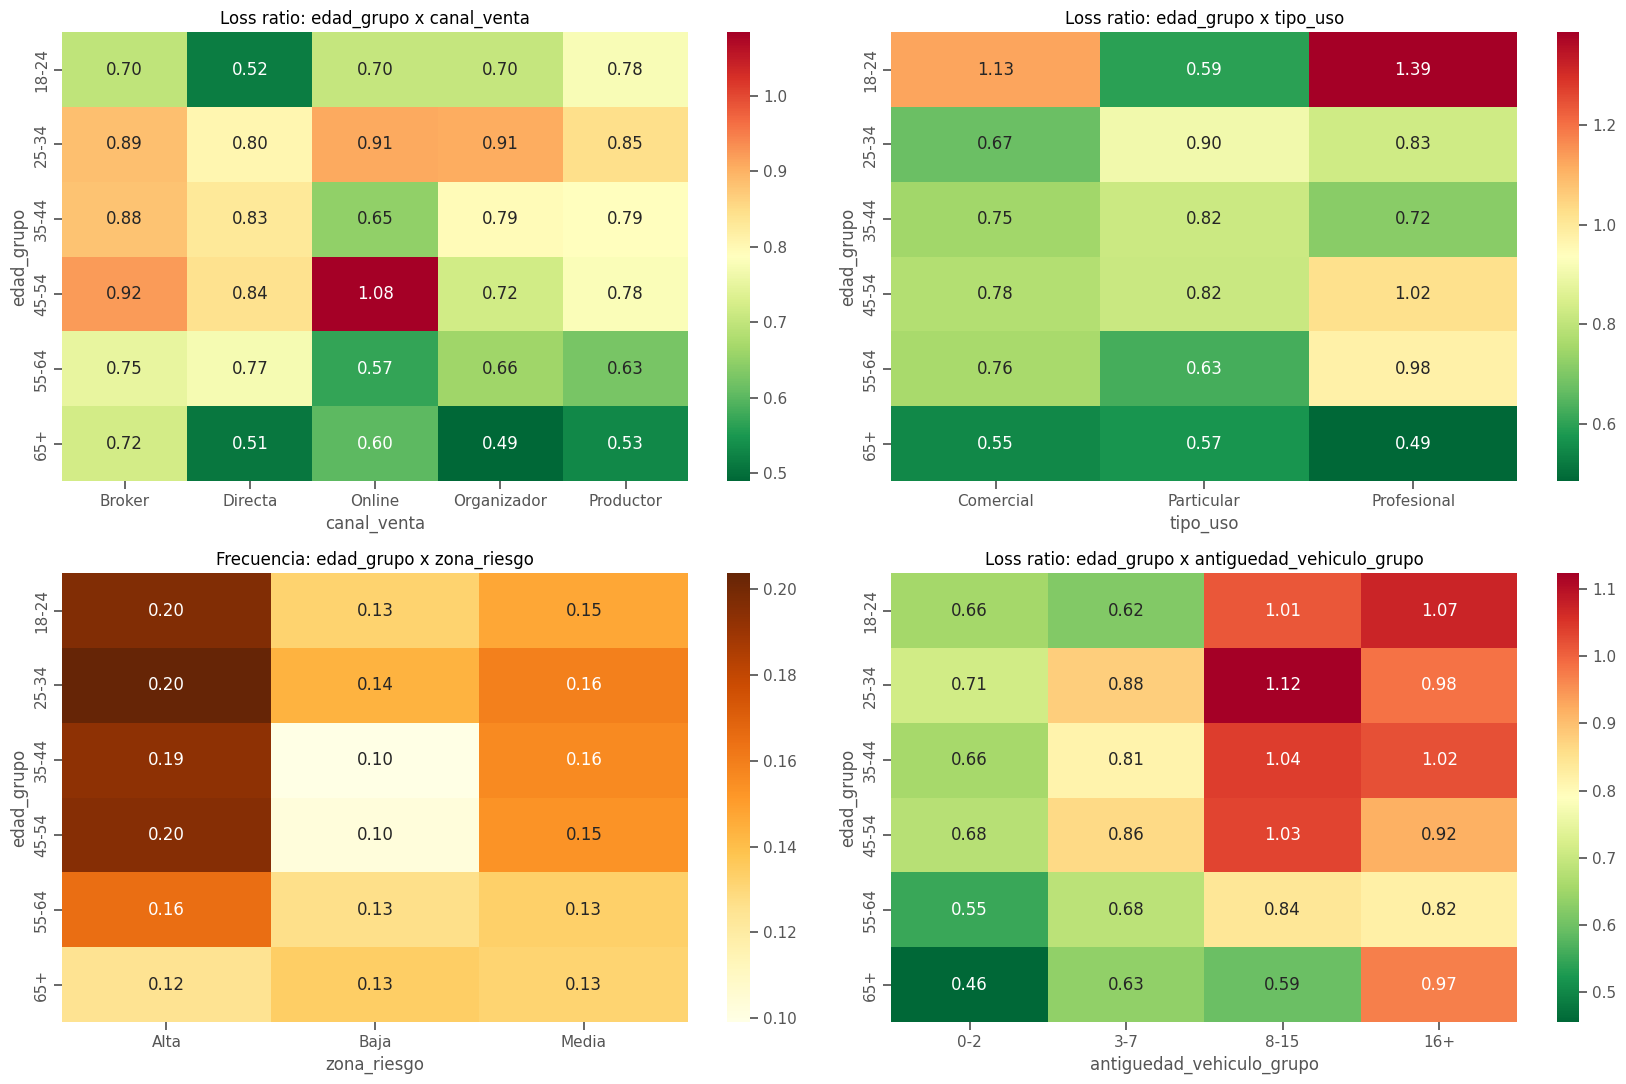

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(17, 11))

sns.heatmap(hm_edad_canal_lr, annot=True, fmt='.2f', cmap='RdYlGn_r', ax=axes[0,0])
axes[0,0].set_title('Loss ratio: edad_grupo x canal_venta')

sns.heatmap(hm_edad_uso_lr, annot=True, fmt='.2f', cmap='RdYlGn_r', ax=axes[0,1])
axes[0,1].set_title('Loss ratio: edad_grupo x tipo_uso')

sns.heatmap(hm_edad_zona_freq, annot=True, fmt='.2f', cmap='YlOrBr', ax=axes[1,0])
axes[1,0].set_title('Frecuencia: edad_grupo x zona_riesgo')

sns.heatmap(hm_edad_antig_lr, annot=True, fmt='.2f', cmap='RdYlGn_r', ax=axes[1,1])
axes[1,1].set_title('Loss ratio: edad_grupo x antiguedad_vehiculo_grupo')

plt.tight_layout()
plt.show()


## 6) Segmentacion multivariable (provincia + cobertura + edad_grupo)

Segmentación en **tres dimensiones simultáneas**: provincia × plan de cobertura × grupo de edad. Se filtran los segmentos con al menos 30 pólizas para garantizar significancia estadística, y se ordenan por LR descendente. Luego se profundiza en la provincia de mayor volumen, mostrando los 10 sub-segmentos más rentables y los 10 peores. Este análisis es la base para decisiones de re-tarificación o restricción de suscripción por segmento.

In [17]:
seg_multi = (
    df_lr.groupby(['provincia', 'plan_cobertura', 'edad_grupo'], as_index=False)
    .agg(
        polizas=('id_poliza', 'count'),
        prima_total=('prima', 'sum'),
        siniestros_total=('siniestros_incurridos', 'sum'),
        frecuencia=('tuvo_siniestro', 'mean')
    )
)
seg_multi['loss_ratio'] = seg_multi['siniestros_total'] / seg_multi['prima_total']
seg_multi_filtrado = seg_multi[seg_multi['polizas'] >= 60].copy()

top_celdas = seg_multi_filtrado.sort_values('loss_ratio', ascending=False).head(25)
display(top_celdas)
print('Celdas analizadas (min 60 polizas):', len(seg_multi_filtrado))


,provincia,plan_cobertura,edad_grupo,polizas,prima_total,siniestros_total,frecuencia,loss_ratio
21,CABA,Responsabilidad Civil,45-54,917,"533,762,998.27","1,003,094,921.73",0.17,1.88
19,CABA,Responsabilidad Civil,25-34,1208,"743,027,253.57","1,390,075,899.10",0.21,1.87
23,CABA,Responsabilidad Civil,65+,208,"126,670,851.99","217,377,053.16",0.15,1.72
20,CABA,Responsabilidad Civil,35-44,1075,"634,381,448.96","1,071,292,613.98",0.20,1.69
38,Catamarca,Responsabilidad Civil,35-44,99,"48,213,023.27","73,504,887.98",0.10,1.52
183,Mendoza,Responsabilidad Civil,45-54,422,"216,785,013.59","325,670,533.99",0.14,1.50
1,Buenos Aires,Responsabilidad Civil,25-34,3950,"2,285,365,253.23","3,262,668,239.16",0.18,1.43
253,Salta,Responsabilidad Civil,25-34,306,"155,387,890.55","207,447,512.33",0.16,1.34
22,CABA,Responsabilidad Civil,55-64,616,"359,241,368.16","468,767,376.47",0.16,1.30
108,Entre Ríos,Responsabilidad Civil,18-24,116,"54,299,937.65","70,332,585.92",0.19,1.30


Celdas analizadas (min 60 polizas): 288


plan_cobertura,Responsabilidad Civil,Terceros Completo,Todo Riesgo
edad_grupo,,,
18-24,0.97,0.67,0.87
25-34,1.43,0.95,0.83
35-44,1.22,0.89,0.77
45-54,1.12,0.86,1.02
55-64,0.88,0.80,0.57
65+,0.79,0.60,0.36


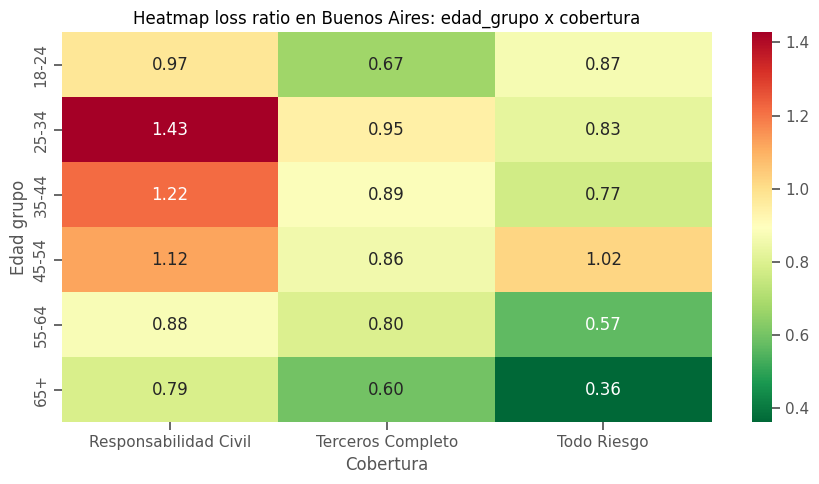

In [18]:
prov_obj = 'Buenos Aires' if (seg_multi_filtrado['provincia'] == 'Buenos Aires').any() else seg_multi_filtrado['provincia'].mode().iloc[0]
base_prov = seg_multi_filtrado[seg_multi_filtrado['provincia'] == prov_obj].copy()

pivot_multi = base_prov.pivot_table(
    index='edad_grupo',
    columns='plan_cobertura',
    values='loss_ratio',
    aggfunc='mean'
)
display(pivot_multi)

plt.figure(figsize=(9, 5))
sns.heatmap(pivot_multi, annot=True, fmt='.2f', cmap='RdYlGn_r')
plt.title(f'Heatmap loss ratio en {prov_obj}: edad_grupo x cobertura')
plt.xlabel('Cobertura')
plt.ylabel('Edad grupo')
plt.tight_layout()
plt.show()


### Ideas para profundizar aun mas
- Ranking de outliers con `loss_ratio_poliza` extremo y validacion de severidad RC.
- Evolucion temporal mensual de frecuencia y severidad para detectar estacionalidad.

## 7) Nuevas variables: distribuciones base

Esta sección presenta las distribuciones de las **nuevas columnas** incorporadas en esta versión del dataset. Se muestran: el ramo regulatorio (`ramo`: "Automotor" vs "Motovehiculos"), el tipo de vehículo, la categoría de cobertura (Solo RC / RC+Casco Básico / RC+Casco Total), la bandera de flota, la asignación a organizador, y la categoría del siniestro (Casco / RC / Mixto). Sirve como verificación de que las proporciones del dataset coinciden con los pesos configurados.

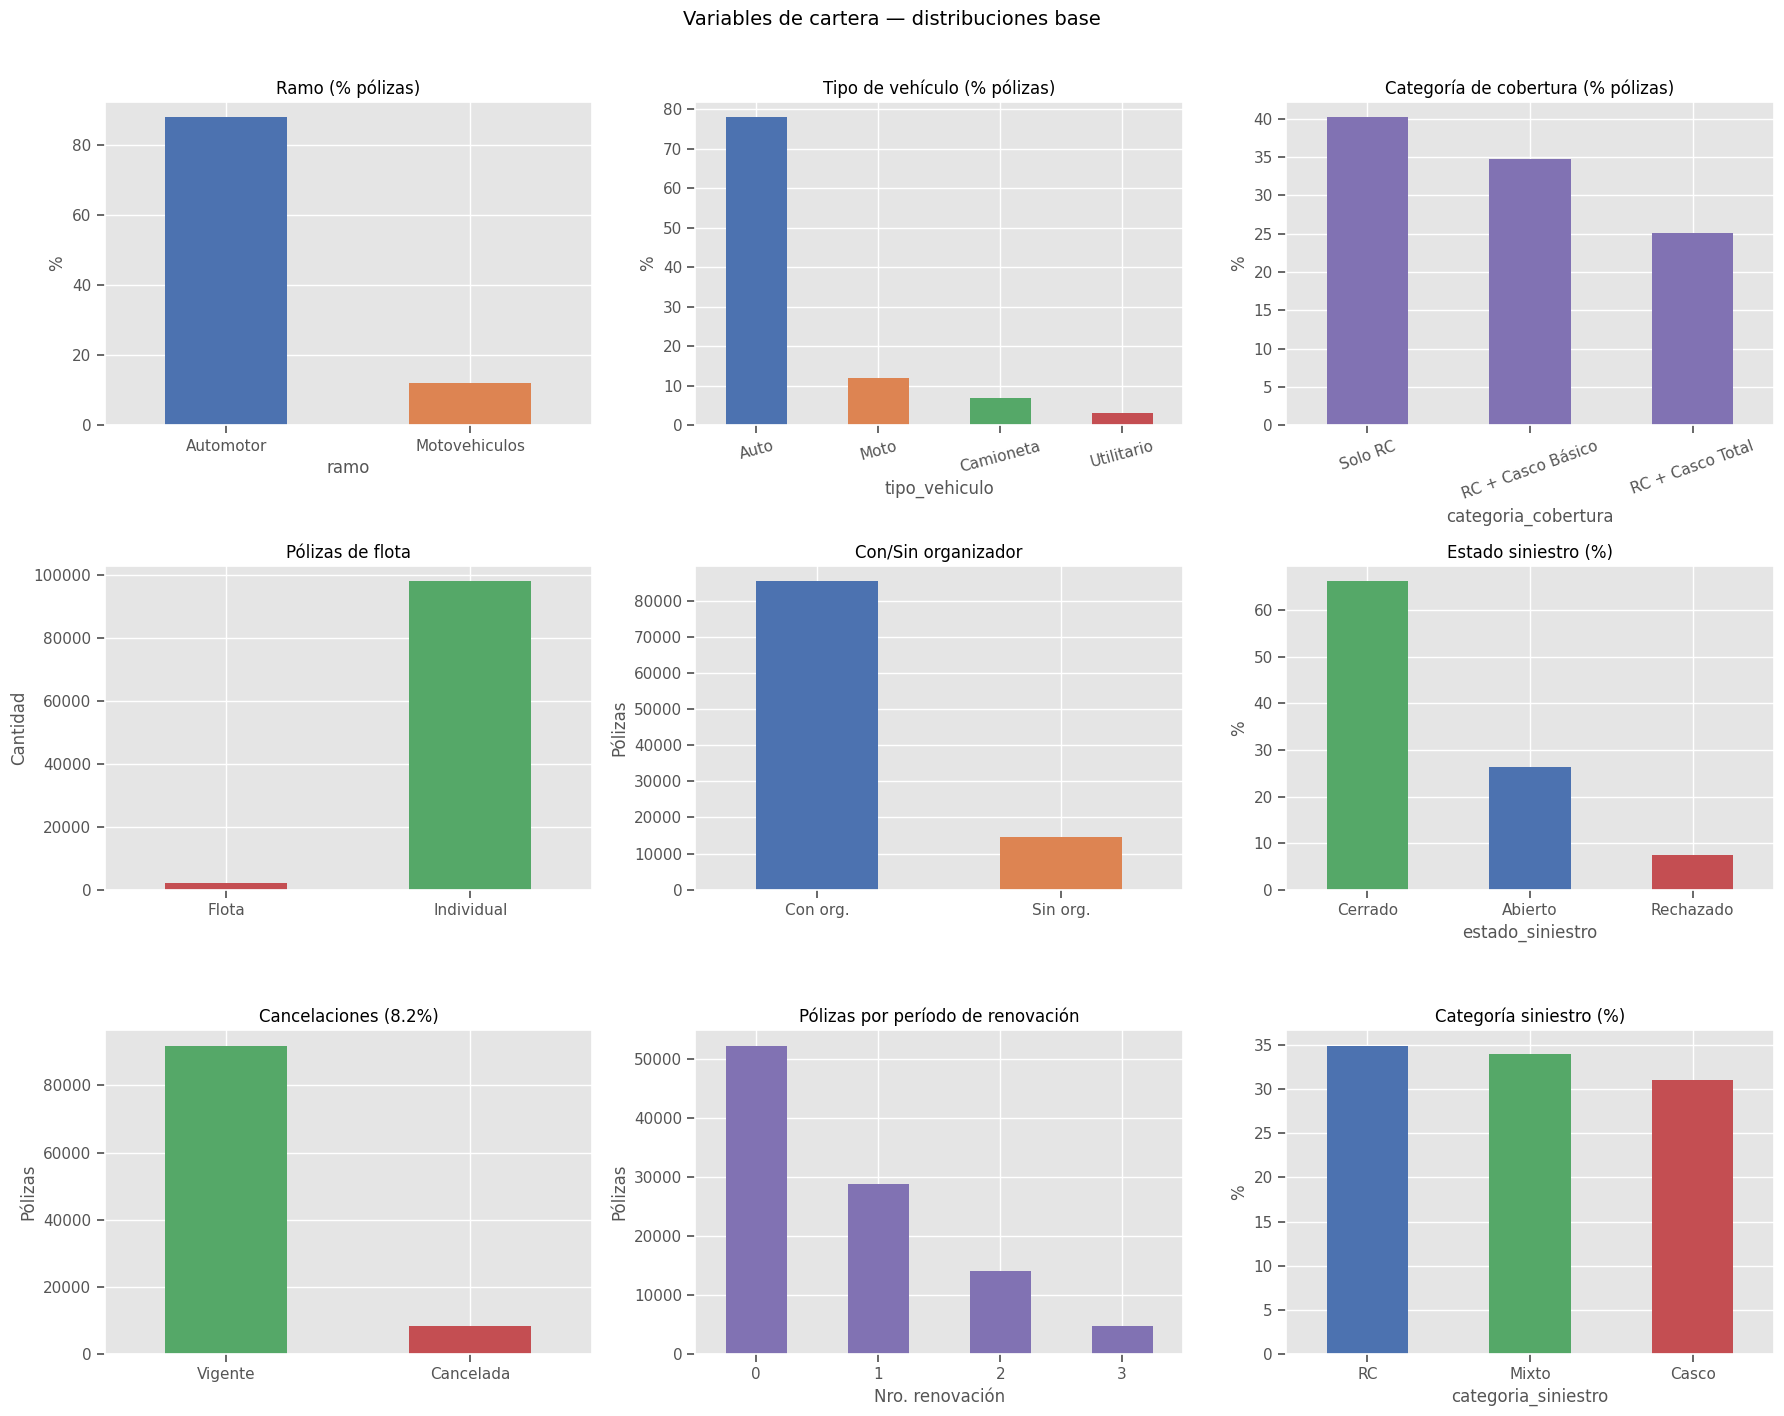

In [19]:

fig, axes = plt.subplots(3, 3, figsize=(18, 14))

# Ramo
if 'ramo' in df_polizas.columns:
    (df_polizas['ramo'].value_counts(normalize=True).mul(100)
     .plot(kind='bar', ax=axes[0, 0], color=['#4c72b0', '#dd8452'],
           title='Ramo (% pólizas)'))
    axes[0, 0].set_ylabel('%'); axes[0, 0].tick_params(axis='x', rotation=0)

# tipo_vehiculo
if 'tipo_vehiculo' in df_polizas.columns:
    (df_polizas['tipo_vehiculo'].value_counts(normalize=True).mul(100)
     .sort_values(ascending=False)
     .plot(kind='bar', ax=axes[0, 1], color=['#4c72b0','#dd8452','#55a868','#c44e52'],
           title='Tipo de vehículo (% pólizas)'))
    axes[0, 1].set_ylabel('%'); axes[0, 1].tick_params(axis='x', rotation=15)

# categoria_cobertura
if 'categoria_cobertura' in df_polizas.columns:
    (df_polizas['categoria_cobertura'].value_counts(normalize=True).mul(100)
     .sort_values(ascending=False)
     .plot(kind='bar', ax=axes[0, 2], color='#8172b3',
           title='Categoría de cobertura (% pólizas)'))
    axes[0, 2].set_ylabel('%'); axes[0, 2].tick_params(axis='x', rotation=20)

# es_flota
if 'es_flota' in df_polizas.columns:
    pd.Series({
        'Flota': df_polizas['es_flota'].sum(),
        'Individual': (~df_polizas['es_flota']).sum()
    }).plot(kind='bar', ax=axes[1, 0], color=['#c44e52', '#55a868'],
            title='Pólizas de flota')
    axes[1, 0].set_ylabel('Cantidad'); axes[1, 0].tick_params(axis='x', rotation=0)

# Organizadores
if 'codigo_organizador' in df_polizas.columns:
    pd.Series({
        'Con org.': df_polizas['codigo_organizador'].notna().sum(),
        'Sin org.': df_polizas['codigo_organizador'].isna().sum()
    }).plot(kind='bar', ax=axes[1, 1], color=['#4c72b0', '#dd8452'],
            title='Con/Sin organizador')
    axes[1, 1].set_ylabel('Pólizas'); axes[1, 1].tick_params(axis='x', rotation=0)

# Estado siniestro (NEW)
if 'estado_siniestro' in df_siniestros.columns:
    (df_siniestros['estado_siniestro'].value_counts(normalize=True).mul(100)
     .plot(kind='bar', ax=axes[1, 2], color=['#55a868','#4c72b0','#c44e52'],
           title='Estado siniestro (%)'))
    axes[1, 2].set_ylabel('%'); axes[1, 2].tick_params(axis='x', rotation=0)

# Cancelada (NEW)
if 'cancelada' in df_polizas.columns:
    pd.Series({
        'Vigente': (~df_polizas['cancelada']).sum(),
        'Cancelada': df_polizas['cancelada'].sum()
    }).plot(kind='bar', ax=axes[2, 0], color=['#55a868', '#c44e52'],
            title=f'Cancelaciones ({df_polizas["cancelada"].mean()*100:.1f}%)')
    axes[2, 0].set_ylabel('Pólizas'); axes[2, 0].tick_params(axis='x', rotation=0)

# Renovaciones / cohortes (NEW)
if 'numero_renovacion' in df_polizas.columns:
    (df_polizas['numero_renovacion'].value_counts().sort_index()
     .plot(kind='bar', ax=axes[2, 1], color='#8172b3',
           title='Pólizas por período de renovación'))
    axes[2, 1].set_xlabel('Nro. renovación'); axes[2, 1].set_ylabel('Pólizas')
    axes[2, 1].tick_params(axis='x', rotation=0)

# categoria_siniestro
if 'categoria_siniestro' in df_siniestros.columns:
    (df_siniestros['categoria_siniestro'].value_counts(normalize=True).mul(100)
     .sort_values(ascending=False)
     .plot(kind='bar', ax=axes[2, 2], color=['#4c72b0','#55a868','#c44e52'],
           title='Categoría siniestro (%)'))
    axes[2, 2].set_ylabel('%'); axes[2, 2].tick_params(axis='x', rotation=0)

plt.suptitle('Variables de cartera — distribuciones base', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()


## 8) Análisis por tipo de vehículo

Comparación del **comportamiento siniestral por tipo de vehículo** (Auto, Moto, Camioneta, Utilitario). Se analiza el LR, la frecuencia de siniestros y la severidad media por tipo. Las motos tienen una frecuencia inherentemente mayor (lambda ×1.7) y distinta distribución de tipos de daño (más choques y daños a terceros, menos granizo). Las camionetas tienen menor frecuencia (lambda ×0.85). Los gráficos incluyen la distribución de tipos de daño por vehículo y boxplots de montos reclamados.

Resumen por tipo de vehículo:


,tipo_vehiculo,polizas,frecuencia,severidad_promedio,loss_ratio
3,Utilitario,3039,0.15,"4,059,008.25",0.91
0,Auto,77917,0.14,"4,129,249.59",0.82
2,Moto,12068,0.23,"1,190,067.84",0.66
1,Camioneta,6976,0.12,"4,000,342.38",0.53


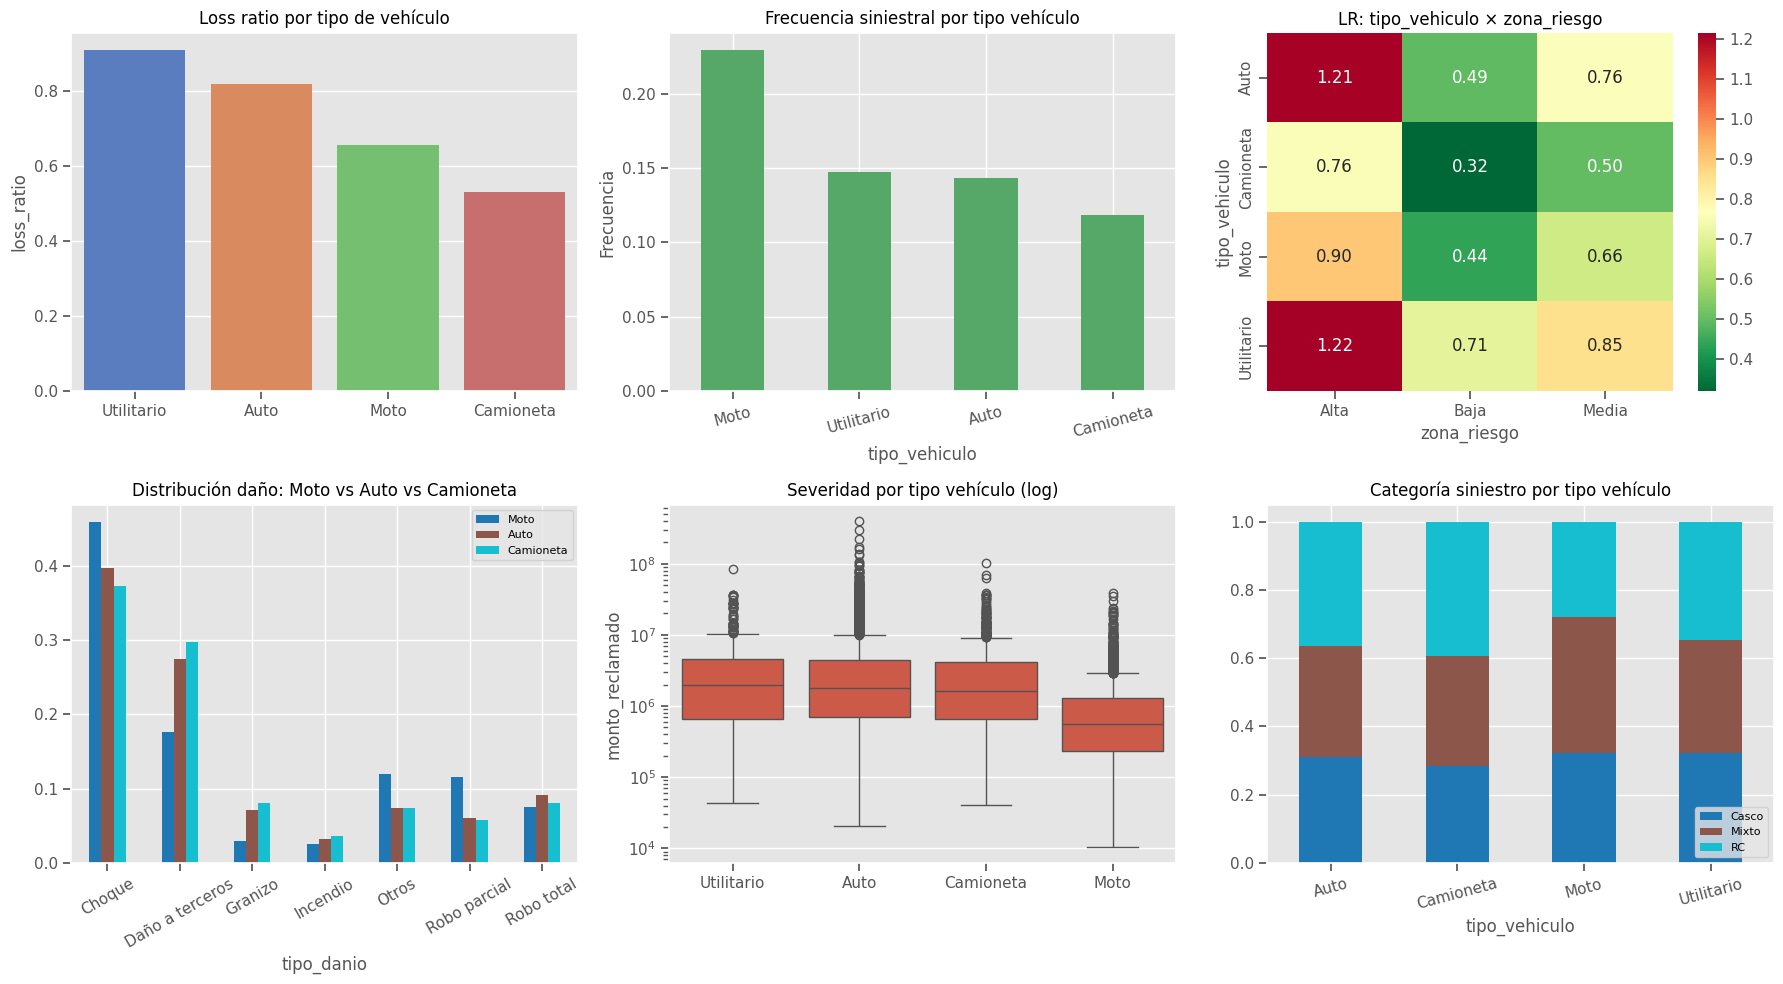

In [20]:

if 'tipo_vehiculo' not in df_lr.columns:
    df_lr = df_lr.merge(df_polizas[['id_poliza', 'tipo_vehiculo']], on='id_poliza', how='left')

# Siniestros enriquecidos con tipo_vehiculo
df_sin_tv = df_siniestros.merge(
    df_polizas[['id_poliza', 'tipo_vehiculo']], on='id_poliza', how='left')

lr_tv = resumen_segmento(df_lr, 'tipo_vehiculo')
print('Resumen por tipo de vehículo:')
display(lr_tv[['tipo_vehiculo', 'polizas', 'frecuencia', 'severidad_promedio', 'loss_ratio']])

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# LR por tipo_vehiculo
sns.barplot(data=lr_tv, x='tipo_vehiculo', y='loss_ratio', ax=axes[0, 0], palette='muted')
axes[0, 0].set_title('Loss ratio por tipo de vehículo'); axes[0, 0].set_xlabel('')

# Frecuencia por tipo_vehiculo
freq_tv = df_lr.groupby('tipo_vehiculo')['tuvo_siniestro'].mean().sort_values(ascending=False)
freq_tv.plot(kind='bar', ax=axes[0, 1], color='#55a868',
             title='Frecuencia siniestral por tipo vehículo')
axes[0, 1].set_ylabel('Frecuencia'); axes[0, 1].tick_params(axis='x', rotation=15)

# Heatmap: tipo_vehiculo × zona_riesgo → LR
hm_tv_zona = (df_lr.groupby(['tipo_vehiculo', 'zona_riesgo'])
              .apply(lambda x: x['siniestros_incurridos'].sum() / x['prima'].sum())
              .unstack())
sns.heatmap(hm_tv_zona, annot=True, fmt='.2f', cmap='RdYlGn_r', ax=axes[0, 2])
axes[0, 2].set_title('LR: tipo_vehiculo × zona_riesgo')

# Distribución de daño: Moto vs Auto
danio_tv = df_sin_tv.groupby(['tipo_vehiculo', 'tipo_danio']).size().unstack(fill_value=0)
danio_tv_pct = danio_tv.div(danio_tv.sum(axis=1), axis=0)
tvs_disponibles = [tv for tv in ['Moto', 'Auto', 'Camioneta'] if tv in danio_tv_pct.index]
danio_tv_pct.loc[tvs_disponibles].T.plot(kind='bar', ax=axes[1, 0], colormap='tab10')
axes[1, 0].set_title('Distribución daño: Moto vs Auto vs Camioneta')
axes[1, 0].tick_params(axis='x', rotation=30); axes[1, 0].legend(loc='upper right', fontsize=8)

# Boxplot severidad por tipo_vehiculo
orden_tv = (df_sin_tv.groupby('tipo_vehiculo')['monto_reclamado']
            .median().sort_values(ascending=False).index)
sns.boxplot(data=df_sin_tv.dropna(subset=['tipo_vehiculo']),
            x='tipo_vehiculo', y='monto_reclamado', order=orden_tv, ax=axes[1, 1])
axes[1, 1].set_yscale('log'); axes[1, 1].set_title('Severidad por tipo vehículo (log)')
axes[1, 1].set_xlabel('')

# categoria_siniestro por tipo_vehiculo (stacked %)
if 'categoria_siniestro' in df_sin_tv.columns:
    cat_tv = df_sin_tv.groupby(['tipo_vehiculo', 'categoria_siniestro']).size().unstack(fill_value=0)
    cat_tv_pct = cat_tv.div(cat_tv.sum(axis=1), axis=0)
    cat_tv_pct.plot(kind='bar', stacked=True, ax=axes[1, 2], colormap='tab10',
                    title='Categoría siniestro por tipo vehículo')
    axes[1, 2].tick_params(axis='x', rotation=15)
    axes[1, 2].legend(loc='lower right', fontsize=8)

plt.tight_layout()
plt.show()


## 9) Organizadores y pólizas de flota

Análisis de la **red de distribución**: los organizadores son grupos de productores (~50 en total) a los que pertenece el 80% de los productores. Se muestran los top 20 organizadores por volumen de primas y su LR respectivo, permitiendo identificar organizadores con peor resultado técnico. También se compara el comportamiento de las **pólizas de flota** (2% del total, forzadas a uso Comercial) frente a las pólizas individuales en términos de LR y monto reclamado medio.

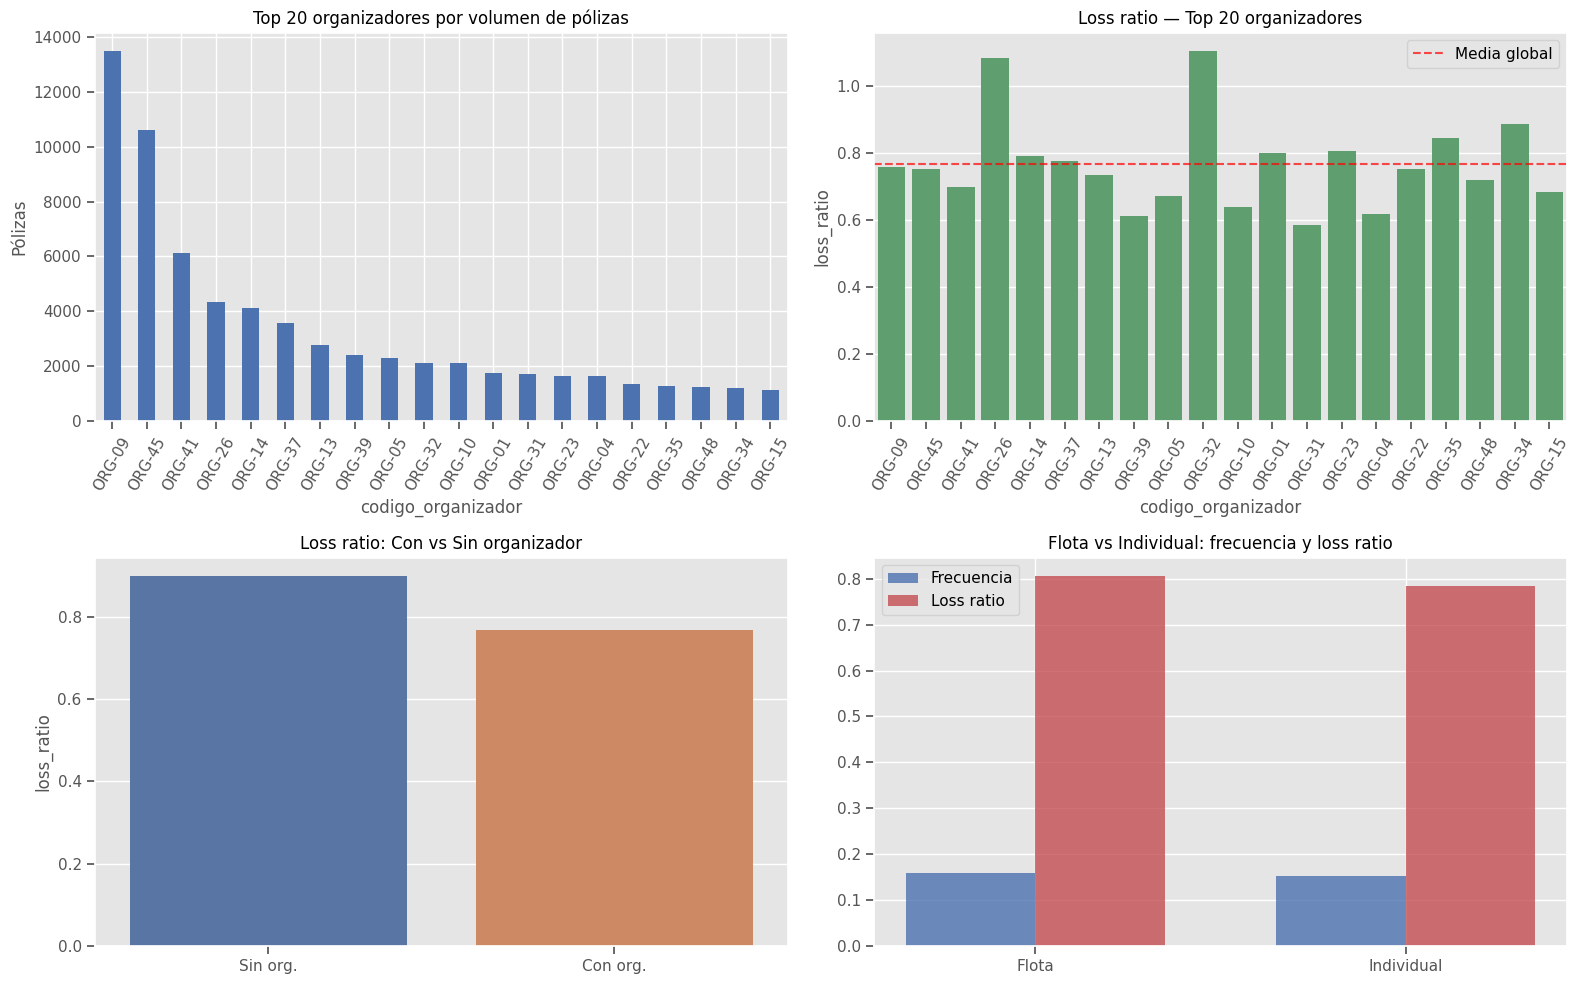

In [21]:

# Enrich df_lr with organizador and flota columns (defensive)
for _col in ['codigo_organizador', 'es_flota']:
    if _col not in df_lr.columns and _col in df_polizas.columns:
        df_lr = df_lr.merge(df_polizas[['id_poliza', _col]], on='id_poliza', how='left')

df_lr['tiene_organizador'] = df_lr['codigo_organizador'].notna() if 'codigo_organizador' in df_lr.columns else False

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# ── Top 20 organizadores por volumen ───────────────────────────────────────
if 'codigo_organizador' in df_lr.columns:
    lr_org = resumen_loss_ratio(df_lr[df_lr['tiene_organizador']], 'codigo_organizador')
    lr_org_top20 = lr_org.sort_values('polizas', ascending=False).head(20)
    lr_org_top20.set_index('codigo_organizador')['polizas'].plot(
        kind='bar', ax=axes[0, 0], color='#4c72b0',
        title='Top 20 organizadores por volumen de pólizas')
    axes[0, 0].set_ylabel('Pólizas'); axes[0, 0].tick_params(axis='x', rotation=60)

    # LR por organizador (top 20 por volumen)
    sns.barplot(data=lr_org_top20, x='codigo_organizador', y='loss_ratio',
                order=lr_org_top20['codigo_organizador'].tolist(), ax=axes[0, 1],
                color='#55a868')
    axes[0, 1].set_title('Loss ratio — Top 20 organizadores')
    axes[0, 1].tick_params(axis='x', rotation=60)
    axes[0, 1].axhline(y=lr_org['loss_ratio'].mean(), color='red',
                       linestyle='--', alpha=0.7, label='Media global')
    axes[0, 1].legend()

    # Con vs sin organizador
    lr_tiene = resumen_loss_ratio(df_lr, 'tiene_organizador')
    lr_tiene['grupo'] = lr_tiene['tiene_organizador'].map({True: 'Con org.', False: 'Sin org.'})
    sns.barplot(data=lr_tiene, x='grupo', y='loss_ratio', ax=axes[1, 0],
                palette=['#4c72b0', '#dd8452'])
    axes[1, 0].set_title('Loss ratio: Con vs Sin organizador')
    axes[1, 0].set_xlabel('')

# ── Flota vs individual ────────────────────────────────────────────────────
if 'es_flota' in df_lr.columns:
    lr_flota = resumen_loss_ratio(df_lr, 'es_flota')
    freq_flota = df_lr.groupby('es_flota')['tuvo_siniestro'].mean()
    lr_flota['frecuencia'] = lr_flota['es_flota'].map(freq_flota.to_dict())
    lr_flota['grupo'] = lr_flota['es_flota'].map({True: 'Flota', False: 'Individual'})

    x = np.arange(2)
    width = 0.35
    axes[1, 1].bar(x - width/2, lr_flota.set_index('grupo')['frecuencia'],
                   width, label='Frecuencia', color='#4c72b0', alpha=0.8)
    axes[1, 1].bar(x + width/2, lr_flota.set_index('grupo')['loss_ratio'],
                   width, label='Loss ratio', color='#c44e52', alpha=0.8)
    axes[1, 1].set_xticks(x)
    axes[1, 1].set_xticklabels(['Flota', 'Individual'])
    axes[1, 1].set_title('Flota vs Individual: frecuencia y loss ratio')
    axes[1, 1].legend()

plt.tight_layout()
plt.show()


## 10) Categorías de cobertura y siniestro

La **categoría de cobertura** clasifica cada póliza en tres niveles: "Solo RC" (solo responsabilidad civil ante terceros), "RC + Casco Básico" (agrega robo y daños parciales al vehículo propio) y "RC + Casco Total" (cobertura completa incluyendo todo riesgo). Se espera que el loss ratio sea más alto en "Solo RC" porque la prima es baja pero los siniestros de terceros pueden ser costosos.

La **categoría de siniestro** clasifica cada reclamo según qué cobertura lo absorbe: "Casco" (daño al vehículo propio), "RC" (daño a terceros) o "Mixto" (ambos). Analizar la distribución por tipo_vehiculo y tipo_danio permite entender el perfil de riesgo de cada segmento.

Loss ratio por categoría de cobertura:


,categoria_cobertura,polizas,prima_total,siniestros_total,loss_ratio
2,Solo RC,40180,"22,032,476,147.66","22,707,165,914.21",1.03
0,RC + Casco Básico,34792,"27,817,250,162.71","19,584,377,495.81",0.70
1,RC + Casco Total,25028,"26,289,511,908.89","17,451,084,701.92",0.66


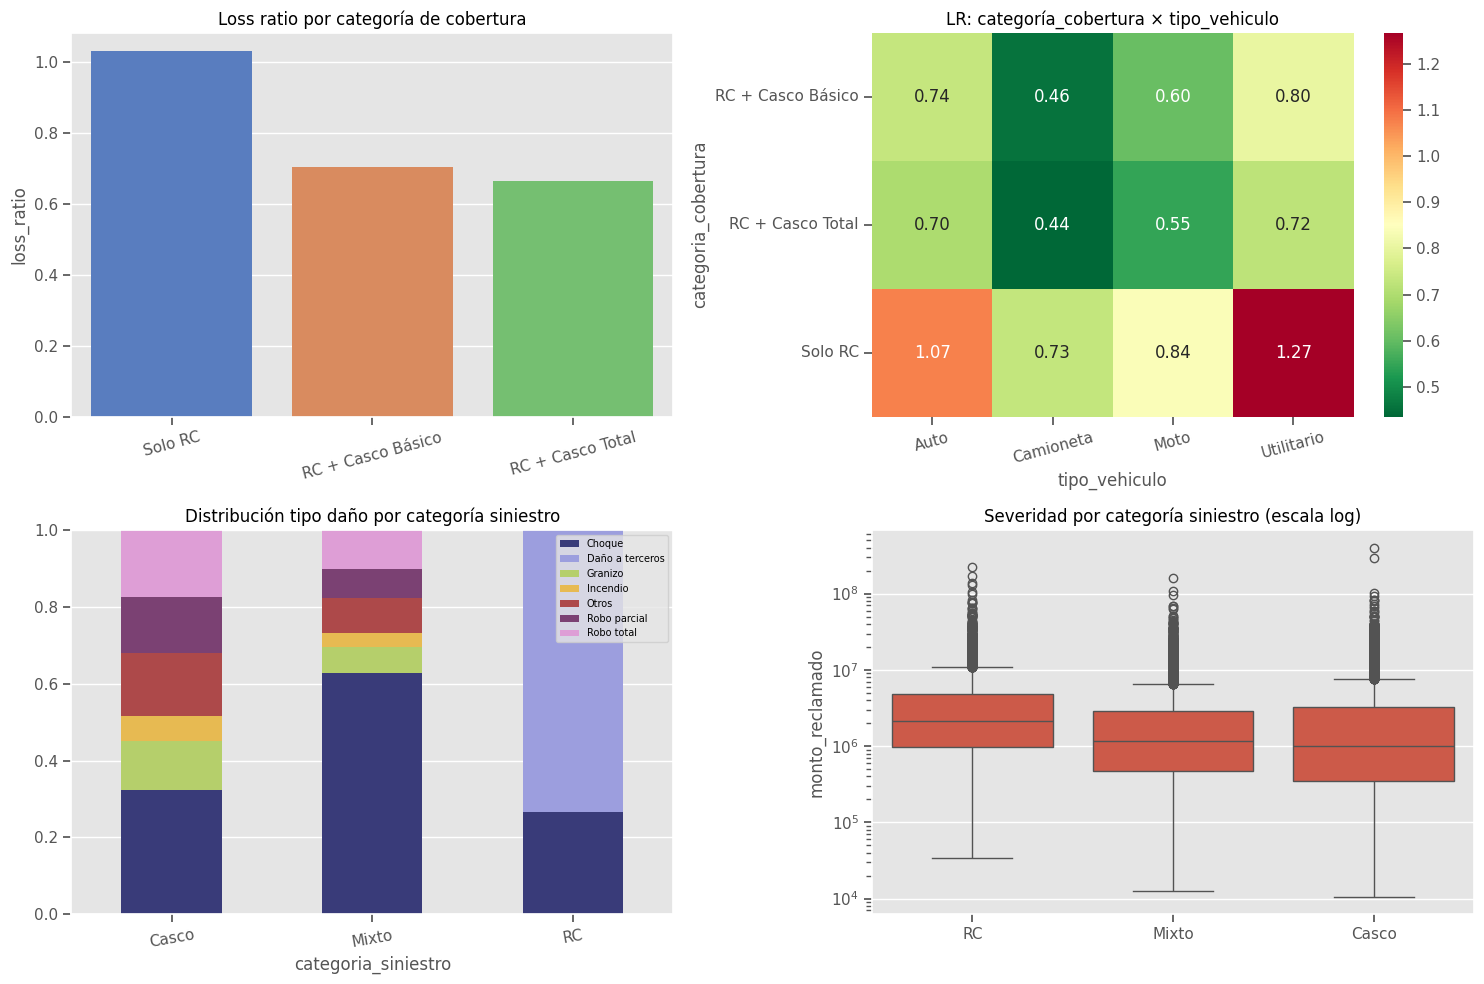

In [22]:

# ── Categoría de cobertura × tipo_vehiculo ──────────────────────────────────
if 'categoria_cobertura' not in df_lr.columns:
    df_lr = df_lr.merge(df_polizas[['id_poliza', 'categoria_cobertura']], on='id_poliza', how='left')

lr_cat_cob = resumen_loss_ratio(df_lr, 'categoria_cobertura')
print('Loss ratio por categoría de cobertura:')
display(lr_cat_cob)

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# LR by categoria_cobertura
sns.barplot(data=lr_cat_cob, x='categoria_cobertura', y='loss_ratio',
            ax=axes[0, 0], palette='muted')
axes[0, 0].set_title('Loss ratio por categoría de cobertura')
axes[0, 0].set_xlabel(''); axes[0, 0].tick_params(axis='x', rotation=15)

# Heatmap: categoria_cobertura × tipo_vehiculo → LR
if 'tipo_vehiculo' in df_lr.columns:
    hm_cob_tv = (df_lr.groupby(['categoria_cobertura', 'tipo_vehiculo'])
                 .apply(lambda x: x['siniestros_incurridos'].sum() / x['prima'].sum())
                 .unstack())
    sns.heatmap(hm_cob_tv, annot=True, fmt='.2f', cmap='RdYlGn_r', ax=axes[0, 1])
    axes[0, 1].set_title('LR: categoría_cobertura × tipo_vehiculo')
    axes[0, 1].tick_params(axis='x', rotation=15)
else:
    axes[0, 1].set_visible(False)

# categoria_siniestro × tipo_danio
if 'categoria_siniestro' in df_siniestros.columns:
    cat_danio = (df_siniestros.groupby(['categoria_siniestro', 'tipo_danio']).size()
                 .unstack(fill_value=0))
    cat_danio_pct = cat_danio.div(cat_danio.sum(axis=1), axis=0)
    cat_danio_pct.plot(kind='bar', stacked=True, ax=axes[1, 0], colormap='tab20b')
    axes[1, 0].set_title('Distribución tipo daño por categoría siniestro')
    axes[1, 0].tick_params(axis='x', rotation=10)
    axes[1, 0].legend(fontsize=7, loc='upper right')

# Severidad por categoria_siniestro
if 'categoria_siniestro' in df_siniestros.columns:
    orden_cat = (df_siniestros.groupby('categoria_siniestro')['monto_reclamado']
                 .median().sort_values(ascending=False).index)
    sns.boxplot(data=df_siniestros, x='categoria_siniestro', y='monto_reclamado',
                order=orden_cat, ax=axes[1, 1])
    axes[1, 1].set_yscale('log')
    axes[1, 1].set_title('Severidad por categoría siniestro (escala log)')
    axes[1, 1].set_xlabel('')

plt.tight_layout()
plt.show()


## 11) Estacionalidad, edad bimodal y outliers

Los gráficos de **estacionalidad** muestran si la frecuencia de siniestros varía según el mes del año para cada tipo de daño. Se espera concentración de Granizo en primavera-verano argentino (Oct–Mar), Choques con leve pico invernal (Jul–Ago por niebla y escarcha) y Robos con pico en diciembre-febrero (vacaciones). El heatmap de mes × tipo_danio confirma visualmente estos patrones.

La **distribución de edad bimodal** refleja dos perfiles de asegurado: conductores jóvenes (~27 años) y maduros (~46 años). El gráfico de densidad por tipo de vehículo permite ver si las motos atraen más a conductores jóvenes.

El histograma de **suma asegurada** muestra la distribución general y los outliers por encima de 45M ARS (vehículos premium o flotas). El gráfico logarítmico del monto reclamado evidencia la cola pesada: la mayoría de siniestros son pequeños, pero existe un ~1% catastrófico con montos 2.5–5× superiores (señal de fraude o accidentes graves).

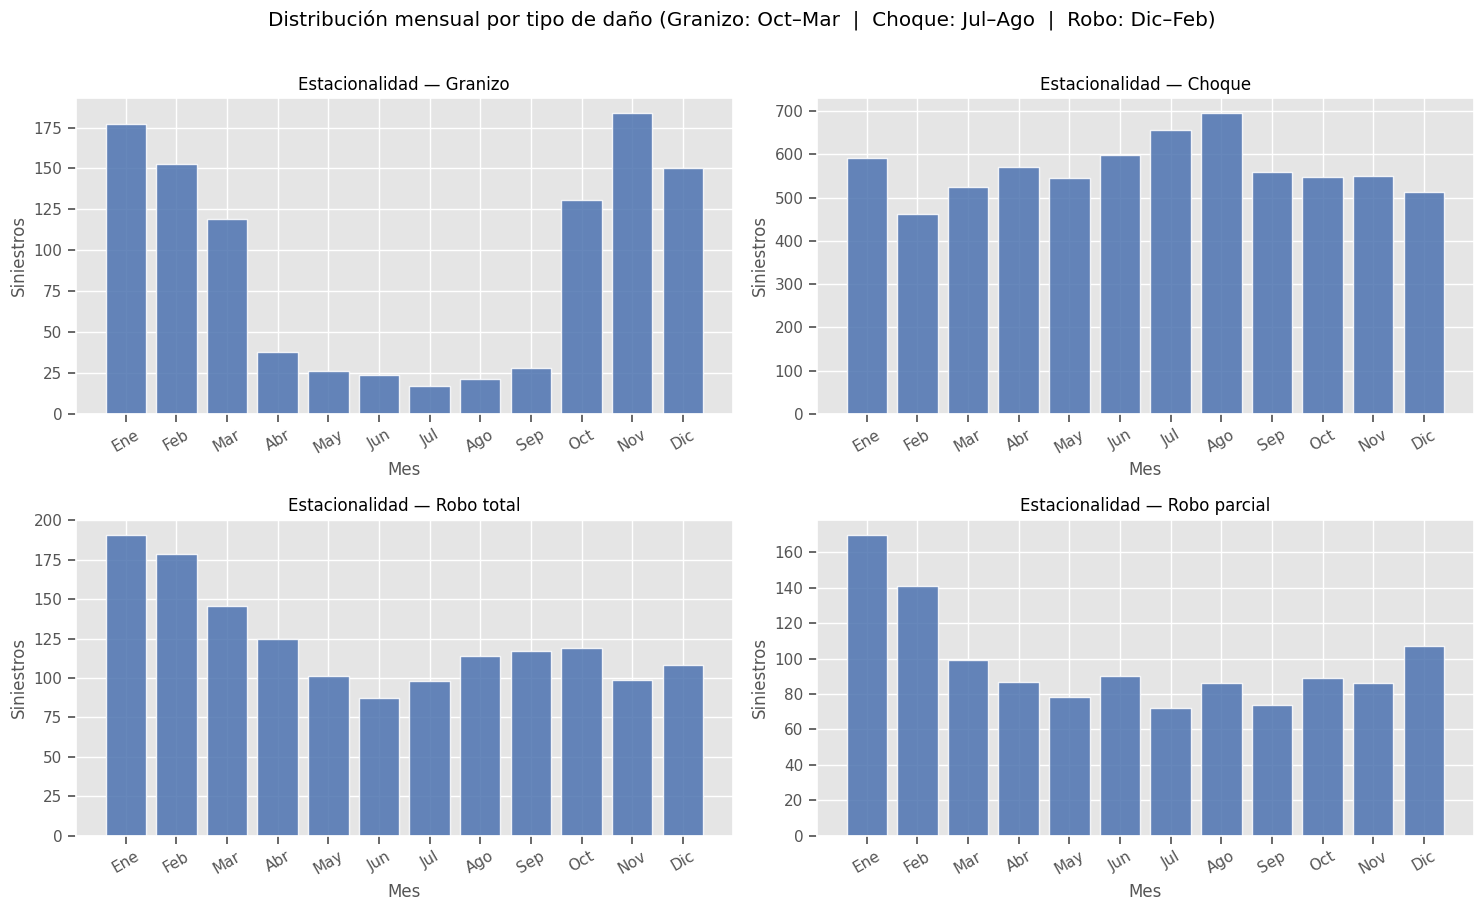

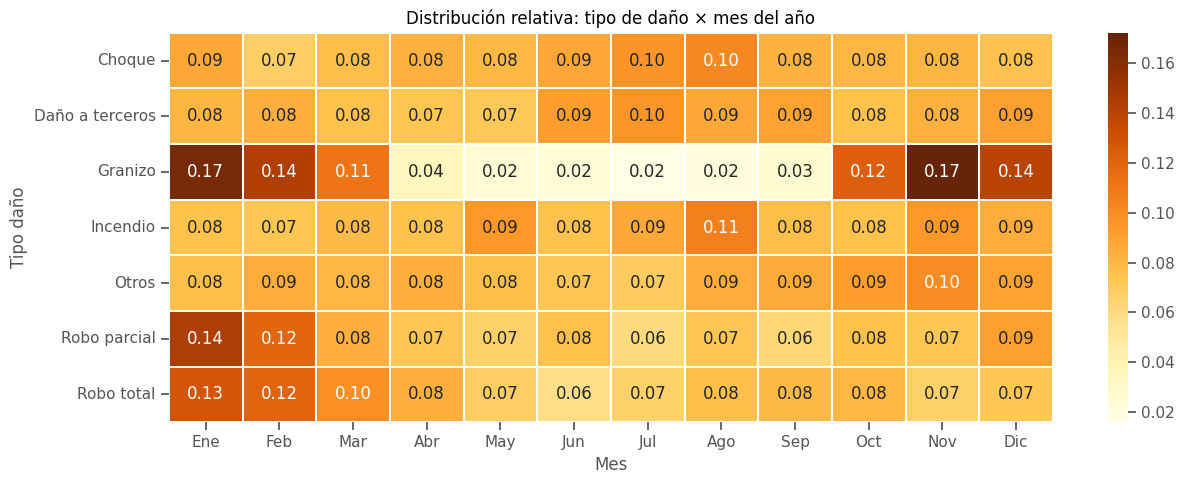

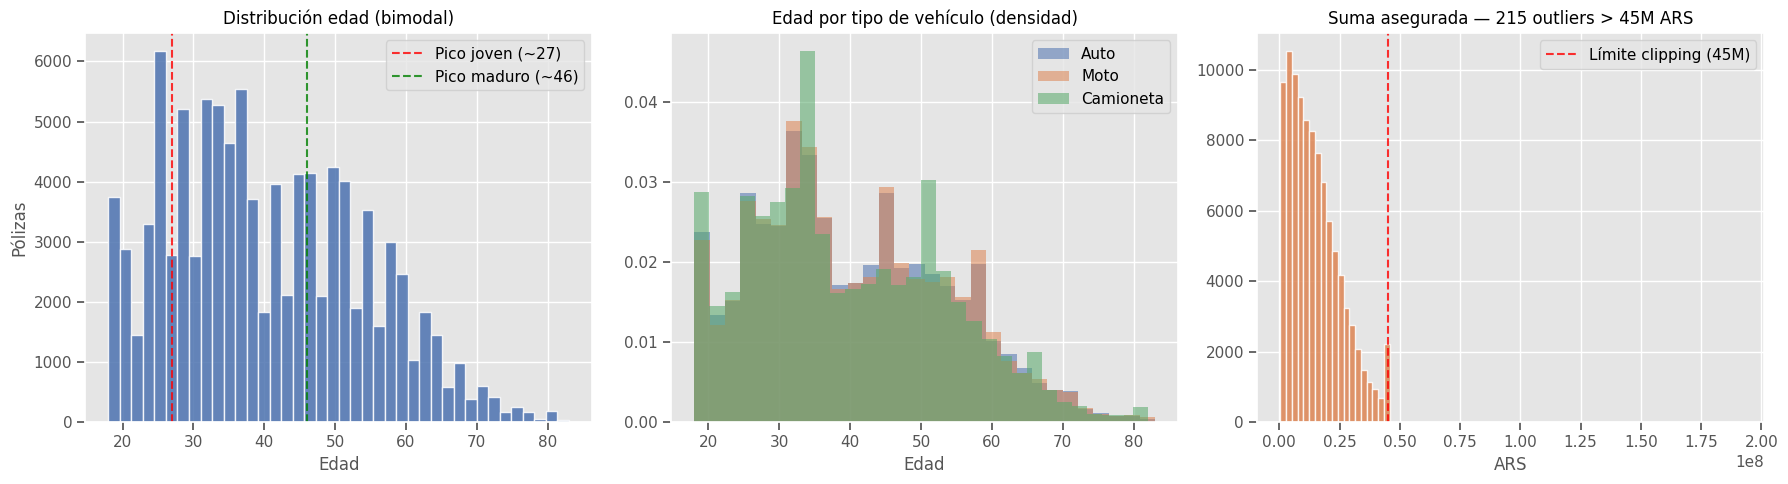

P99 monto reclamado : ARS 30,960,786
Siniestros > 10× mediana: 750 (4.48%)


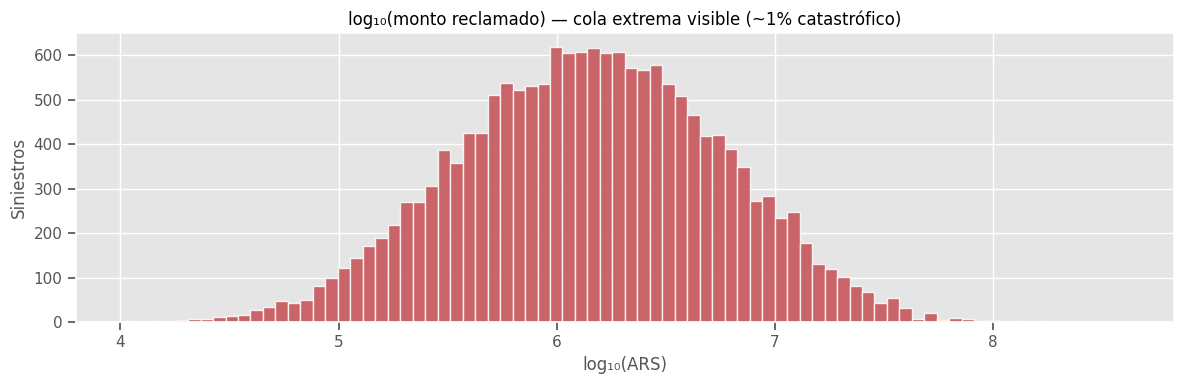

In [23]:

# ── Estacionalidad por tipo de daño ─────────────────────────────────────────
df_siniestros['mes_siniestro'] = df_siniestros['fecha_siniestro'].dt.month
NOMBRES_MES = {1:'Ene',2:'Feb',3:'Mar',4:'Abr',5:'May',6:'Jun',
               7:'Jul',8:'Ago',9:'Sep',10:'Oct',11:'Nov',12:'Dic'}

tipos_clave = ['Granizo', 'Choque', 'Robo total', 'Robo parcial']
fig, axes = plt.subplots(2, 2, figsize=(15, 9))
for ax, tipo in zip(axes.flat, tipos_clave):
    sub = df_siniestros[df_siniestros['tipo_danio'] == tipo]
    conteo = sub.groupby('mes_siniestro').size().reindex(range(1, 13), fill_value=0)
    conteo.index = conteo.index.map(NOMBRES_MES)
    ax.bar(conteo.index, conteo.values, color='#4c72b0', alpha=0.85, edgecolor='white')
    ax.set_title(f'Estacionalidad — {tipo}')
    ax.set_xlabel('Mes'); ax.set_ylabel('Siniestros')
    ax.tick_params(axis='x', rotation=30)
plt.suptitle('Distribución mensual por tipo de daño (Granizo: Oct–Mar  |  Choque: Jul–Ago  |  Robo: Dic–Feb)', y=1.01)
plt.tight_layout()
plt.show()

# Heatmap mes × tipo_danio
pivot_mes = (df_siniestros.groupby(['mes_siniestro', 'tipo_danio']).size()
             .unstack(fill_value=0))
pivot_mes.index = pivot_mes.index.map(NOMBRES_MES)
pivot_mes_pct = pivot_mes.div(pivot_mes.sum(axis=0), axis=1)
plt.figure(figsize=(13, 5))
sns.heatmap(pivot_mes_pct.T, annot=True, fmt='.2f', cmap='YlOrBr', linewidths=0.3)
plt.title('Distribución relativa: tipo de daño × mes del año')
plt.xlabel('Mes'); plt.ylabel('Tipo daño')
plt.tight_layout()
plt.show()

# ── Distribución de edad bimodal ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(df_polizas['edad_asegurado'], bins=40, color='#4c72b0', alpha=0.85, edgecolor='white')
axes[0].set_title('Distribución edad (bimodal)')
axes[0].set_xlabel('Edad'); axes[0].set_ylabel('Pólizas')
axes[0].axvline(27, color='red',   linestyle='--', alpha=0.8, label='Pico joven (~27)')
axes[0].axvline(46, color='green', linestyle='--', alpha=0.8, label='Pico maduro (~46)')
axes[0].legend()

if 'tipo_vehiculo' in df_polizas.columns:
    palette_tv = {'Auto': '#4c72b0', 'Moto': '#dd8452', 'Camioneta': '#55a868'}
    for tv, color in palette_tv.items():
        sub = df_polizas.loc[df_polizas['tipo_vehiculo'] == tv, 'edad_asegurado']
        if len(sub) > 0:
            axes[1].hist(sub, bins=30, alpha=0.55, label=tv, color=color, density=True)
    axes[1].set_title('Edad por tipo de vehículo (densidad)')
    axes[1].set_xlabel('Edad'); axes[1].legend()
else:
    axes[1].set_visible(False)

# suma_asegurada con outliers
axes[2].hist(df_polizas['suma_asegurada'], bins=80, color='#dd8452', alpha=0.85, edgecolor='white')
axes[2].axvline(45_000_000, color='red', linestyle='--', alpha=0.8, label='Límite clipping (45M)')
n_outliers = (df_polizas['suma_asegurada'] > 45_000_000).sum()
axes[2].set_title(f'Suma asegurada — {n_outliers} outliers > 45M ARS')
axes[2].set_xlabel('ARS'); axes[2].legend()
plt.tight_layout()
plt.show()

# Cola extrema de siniestros
q99 = df_siniestros['monto_reclamado'].quantile(0.99)
n_extreme = (df_siniestros['monto_reclamado'] > df_siniestros['monto_reclamado'].median() * 10).sum()
print(f'P99 monto reclamado : ARS {q99:,.0f}')
print(f'Siniestros > 10× mediana: {n_extreme} ({n_extreme/len(df_siniestros)*100:.2f}%)')

plt.figure(figsize=(12, 4))
plt.hist(np.log10(df_siniestros['monto_reclamado'].clip(lower=1)), bins=80,
         color='#c44e52', alpha=0.85, edgecolor='white')
plt.title('log₁₀(monto reclamado) — cola extrema visible (~1% catastrófico)')
plt.xlabel('log₁₀(ARS)'); plt.ylabel('Siniestros')
plt.tight_layout()
plt.show()


## 12) Estado del siniestro, reservas y pagos

Cada siniestro tiene un **estado** (Cerrado, Abierto, Rechazado) y tres columnas financieras:
- `monto_reclamado`: lo que reclama el asegurado.
- `monto_reservado`: estimación inicial de la aseguradora (puede diferir del reclamado).
- `monto_pagado`: lo efectivamente liquidado (0 para rechazados, parcial para abiertos).

Se analiza la distribución de estados, la brecha reserva vs pago, y el desglose por tipo de daño.

,estado_siniestro,cantidad,monto_reclamado_medio,monto_pagado_medio,monto_reservado_medio
0,Abierto,4419,"3,619,712.56","707,055.26","3,880,032.10"
1,Cerrado,11089,"3,529,733.77","3,096,652.64","3,781,921.09"
2,Rechazado,1249,"3,687,670.54",0.00,"3,988,231.92"


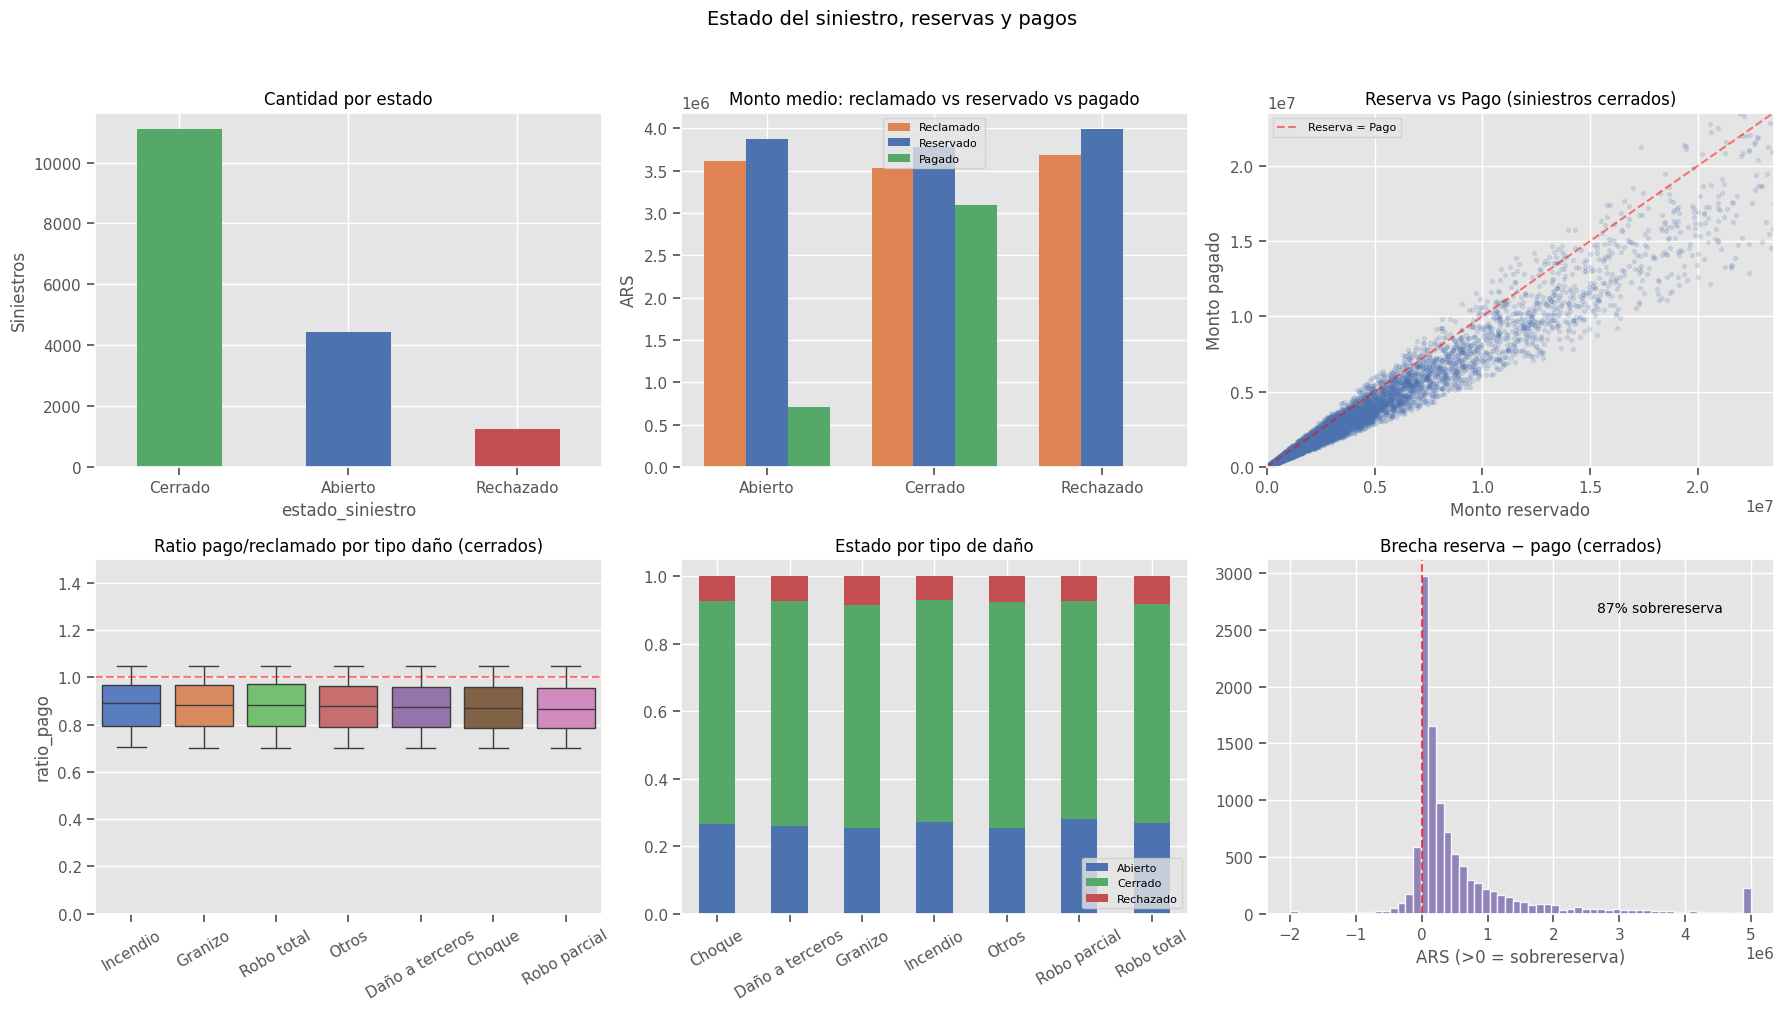

In [24]:

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1. Estado siniestro: distribución y monto medio
estado_stats = (df_siniestros.groupby('estado_siniestro', as_index=False)
                .agg(cantidad=('id_siniestro','count'),
                     monto_reclamado_medio=('monto_reclamado','mean'),
                     monto_pagado_medio=('monto_pagado','mean'),
                     monto_reservado_medio=('monto_reservado','mean')))
display(estado_stats)

colores_estado = {'Cerrado': '#55a868', 'Abierto': '#4c72b0', 'Rechazado': '#c44e52'}
df_siniestros['estado_siniestro'].value_counts().plot(
    kind='bar', ax=axes[0, 0], color=[colores_estado.get(x, '#999') for x in df_siniestros['estado_siniestro'].value_counts().index])
axes[0, 0].set_title('Cantidad por estado'); axes[0, 0].set_ylabel('Siniestros')
axes[0, 0].tick_params(axis='x', rotation=0)

# 2. Monto medio reclamado vs pagado por estado
x = np.arange(len(estado_stats))
w = 0.25
axes[0, 1].bar(x - w, estado_stats['monto_reclamado_medio'], w, label='Reclamado', color='#dd8452')
axes[0, 1].bar(x, estado_stats['monto_reservado_medio'], w, label='Reservado', color='#4c72b0')
axes[0, 1].bar(x + w, estado_stats['monto_pagado_medio'], w, label='Pagado', color='#55a868')
axes[0, 1].set_xticks(x); axes[0, 1].set_xticklabels(estado_stats['estado_siniestro'])
axes[0, 1].set_title('Monto medio: reclamado vs reservado vs pagado')
axes[0, 1].set_ylabel('ARS'); axes[0, 1].legend(fontsize=8)

# 3. Reserva vs pago (scatter, solo cerrados)
cerrados = df_siniestros[df_siniestros['estado_siniestro'] == 'Cerrado']
axes[0, 2].scatter(cerrados['monto_reservado'], cerrados['monto_pagado'],
                   alpha=0.15, s=8, color='#4c72b0')
lim = max(cerrados['monto_reservado'].quantile(0.98), cerrados['monto_pagado'].quantile(0.98))
axes[0, 2].plot([0, lim], [0, lim], 'r--', alpha=0.5, label='Reserva = Pago')
axes[0, 2].set_xlim(0, lim); axes[0, 2].set_ylim(0, lim)
axes[0, 2].set_title('Reserva vs Pago (siniestros cerrados)')
axes[0, 2].set_xlabel('Monto reservado'); axes[0, 2].set_ylabel('Monto pagado')
axes[0, 2].legend(fontsize=8)

# 4. Ratio pago/reclamado por tipo de daño (solo cerrados)
cerrados_td = cerrados.copy()
cerrados_td['ratio_pago'] = cerrados_td['monto_pagado'] / cerrados_td['monto_reclamado'].clip(lower=1)
orden_td = cerrados_td.groupby('tipo_danio')['ratio_pago'].median().sort_values(ascending=False).index
sns.boxplot(data=cerrados_td, x='tipo_danio', y='ratio_pago', order=orden_td,
            ax=axes[1, 0], palette='muted')
axes[1, 0].axhline(1.0, color='red', linestyle='--', alpha=0.5)
axes[1, 0].set_title('Ratio pago/reclamado por tipo daño (cerrados)')
axes[1, 0].set_ylim(0, 1.5); axes[1, 0].tick_params(axis='x', rotation=30); axes[1, 0].set_xlabel('')

# 5. Estado por tipo de daño (stacked %)
estado_danio = df_siniestros.groupby(['tipo_danio', 'estado_siniestro']).size().unstack(fill_value=0)
estado_danio_pct = estado_danio.div(estado_danio.sum(axis=1), axis=0)
estado_danio_pct.plot(kind='bar', stacked=True, ax=axes[1, 1],
                      color=[colores_estado.get(c, '#999') for c in estado_danio_pct.columns])
axes[1, 1].set_title('Estado por tipo de daño'); axes[1, 1].tick_params(axis='x', rotation=30)
axes[1, 1].legend(fontsize=8, loc='lower right'); axes[1, 1].set_xlabel('')

# 6. Brecha reserva-pago: distribución
cerrados['brecha_reserva'] = cerrados['monto_reservado'] - cerrados['monto_pagado']
axes[1, 2].hist(cerrados['brecha_reserva'].clip(-2_000_000, 5_000_000),
                bins=60, color='#8172b3', alpha=0.85, edgecolor='white')
axes[1, 2].axvline(0, color='red', linestyle='--', alpha=0.7)
axes[1, 2].set_title('Brecha reserva − pago (cerrados)')
axes[1, 2].set_xlabel('ARS (>0 = sobrereserva)')
pct_sobre = (cerrados['brecha_reserva'] > 0).mean() * 100
axes[1, 2].annotate(f'{pct_sobre:.0f}% sobrereserva', xy=(0.65, 0.85),
                    xycoords='axes fraction', fontsize=10)

plt.suptitle('Estado del siniestro, reservas y pagos', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()


## 13) Motivos de rechazo

Los siniestros rechazados tienen un **motivo_rechazo** asignado con sesgos contextuales:
pólizas con RC y sin cobertura Casco tienden a rechazarse por *Falta de cobertura*; pólizas con mora alta tienden a rechazarse por *Mora en el pago*. Se analiza la distribución de motivos y su relación con plan de cobertura y zona.

Siniestros rechazados: 1249 (7.5% del total)


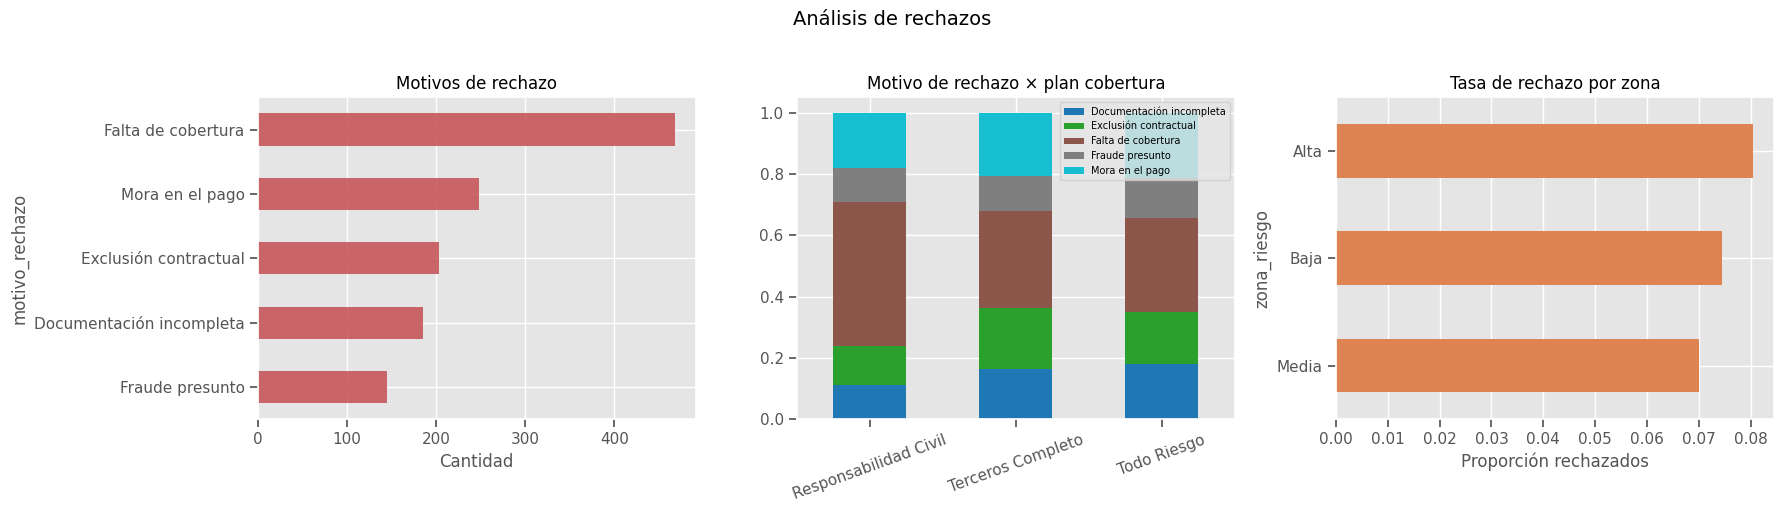

In [25]:

rechazados = df_siniestros[df_siniestros['estado_siniestro'] == 'Rechazado'].copy()
rechazados = rechazados.merge(df_polizas[['id_poliza','plan_cobertura','zona_riesgo','meses_en_mora']], on='id_poliza', how='left')
print(f'Siniestros rechazados: {len(rechazados)} ({len(rechazados)/len(df_siniestros)*100:.1f}% del total)')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Distribución de motivos
rechazados['motivo_rechazo'].value_counts().sort_values().plot(
    kind='barh', ax=axes[0], color='#c44e52', alpha=0.85)
axes[0].set_title('Motivos de rechazo'); axes[0].set_xlabel('Cantidad')

# 2. Motivo × cobertura (stacked %)
if len(rechazados) > 20:
    mot_cob = rechazados.groupby(['plan_cobertura', 'motivo_rechazo']).size().unstack(fill_value=0)
    mot_cob_pct = mot_cob.div(mot_cob.sum(axis=1), axis=0)
    mot_cob_pct.plot(kind='bar', stacked=True, ax=axes[1], colormap='tab10')
    axes[1].set_title('Motivo de rechazo × plan cobertura')
    axes[1].tick_params(axis='x', rotation=20); axes[1].legend(fontsize=7, loc='upper right')
    axes[1].set_xlabel('')

# 3. Tasa de rechazo por zona
tasa_rej_zona = (df_siniestros.merge(df_polizas[['id_poliza','zona_riesgo']], on='id_poliza', how='left')
                 .groupby('zona_riesgo')['estado_siniestro']
                 .apply(lambda x: (x == 'Rechazado').mean()))
tasa_rej_zona.sort_values().plot(kind='barh', ax=axes[2], color='#dd8452')
axes[2].set_title('Tasa de rechazo por zona'); axes[2].set_xlabel('Proporción rechazados')

plt.suptitle('Análisis de rechazos', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


## 14) Combined ratio y gastos de liquidación

El **combined ratio** es la métrica más completa de rentabilidad técnica: `CR = loss_ratio_pagado + expense_ratio`. Un CR > 1 indica pérdida técnica.

Los `gastos de liquidación` incluyen honorarios de peritos, costas legales y gastos administrativos. Se amplifican en siniestros con mediación (×1.4) y juicio (×2.5). Se analiza el combined ratio por segmento y la composición de costos.

,zona_riesgo,polizas,lr_reclamado,lr_pagado,expense_ratio,combined_ratio
0,Alta,25678,1.15,0.71,0.07,0.78
2,Media,43754,0.73,0.46,0.04,0.51
1,Baja,30568,0.48,0.30,0.03,0.33


,plan_cobertura,polizas,lr_reclamado,lr_pagado,expense_ratio,combined_ratio
0,Responsabilidad Civil,40180,1.03,0.65,0.06,0.71
1,Terceros Completo,34792,0.70,0.44,0.04,0.48
2,Todo Riesgo,25028,0.66,0.42,0.04,0.46


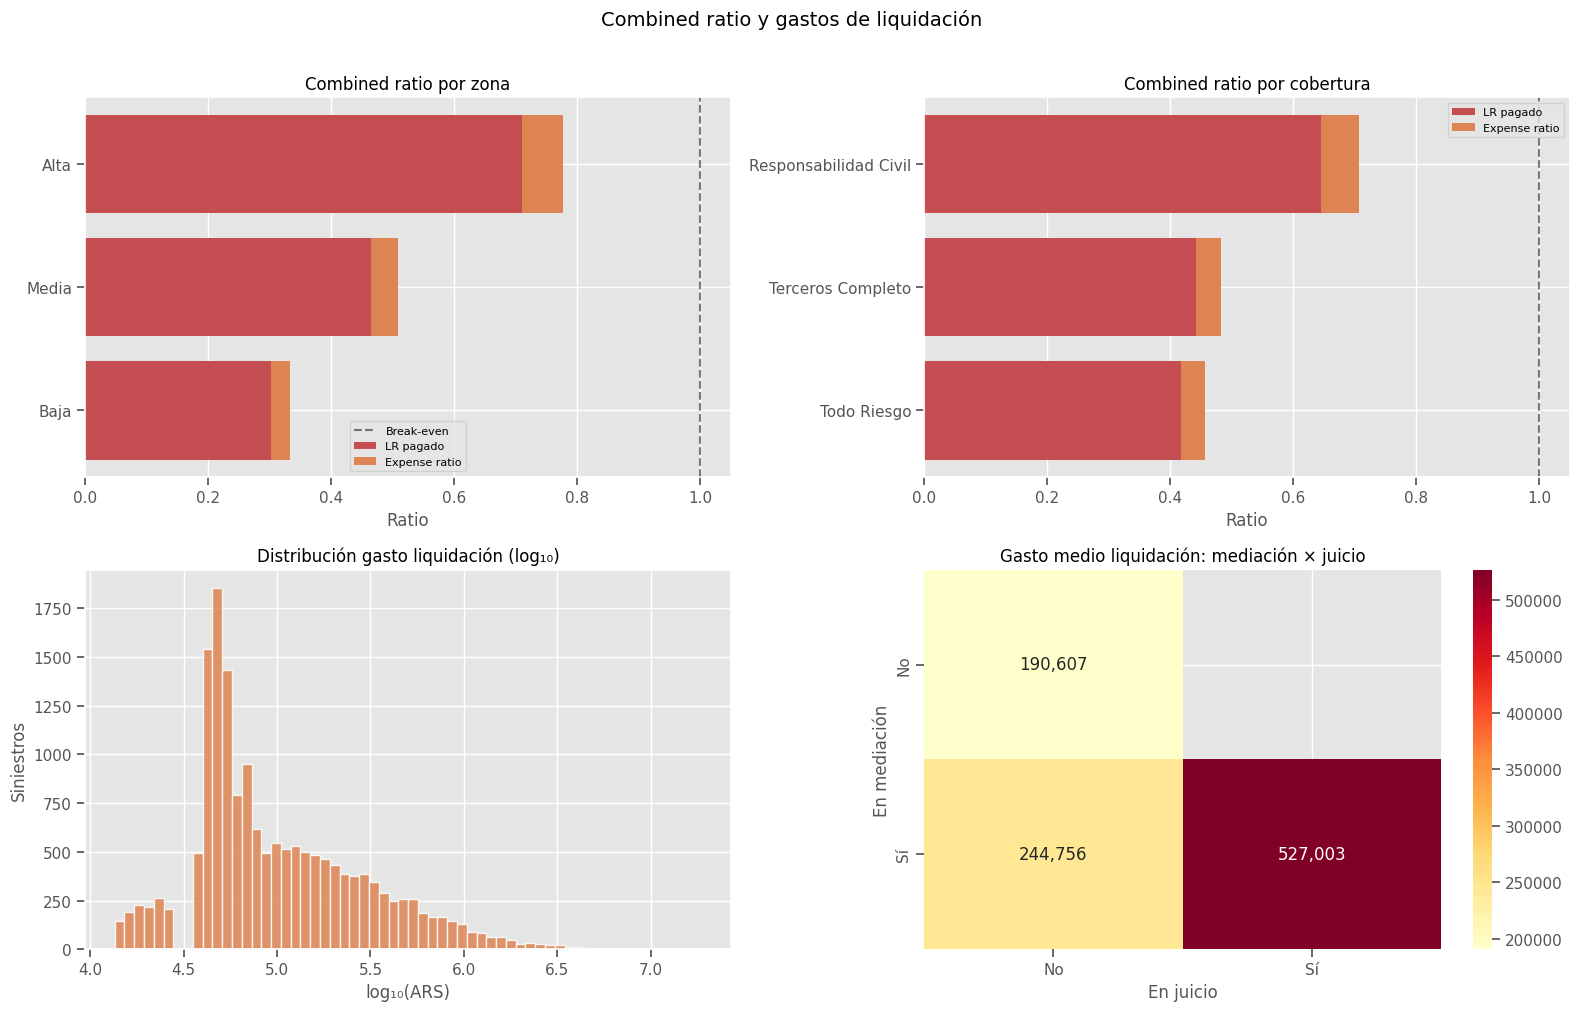

In [26]:

def resumen_combined(df, grupo):
    # Combined ratio by segment
    t = (df.groupby(grupo, as_index=False)
         .agg(polizas=('id_poliza','count'),
              prima_total=('prima','sum'),
              pagos_total=('pagos_totales','sum'),
              gastos_total=('gastos_totales','sum'),
              siniestros_total=('siniestros_incurridos','sum')))
    t['lr_reclamado'] = t['siniestros_total'] / t['prima_total']
    t['lr_pagado'] = t['pagos_total'] / t['prima_total']
    t['expense_ratio'] = t['gastos_total'] / t['prima_total']
    t['combined_ratio'] = t['lr_pagado'] + t['expense_ratio']
    return t.sort_values('combined_ratio', ascending=False)

cr_zona = resumen_combined(df_lr, 'zona_riesgo')
cr_cobertura = resumen_combined(df_lr, 'plan_cobertura')
cr_canal = resumen_combined(df_lr, 'canal_venta')

display(cr_zona[['zona_riesgo','polizas','lr_reclamado','lr_pagado','expense_ratio','combined_ratio']])
display(cr_cobertura[['plan_cobertura','polizas','lr_reclamado','lr_pagado','expense_ratio','combined_ratio']])

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. Combined ratio por zona (stacked: LR pagado + expense)
cr_zona_sorted = cr_zona.sort_values('combined_ratio', ascending=True)
axes[0, 0].barh(cr_zona_sorted['zona_riesgo'], cr_zona_sorted['lr_pagado'],
                color='#c44e52', label='LR pagado')
axes[0, 0].barh(cr_zona_sorted['zona_riesgo'], cr_zona_sorted['expense_ratio'],
                left=cr_zona_sorted['lr_pagado'], color='#dd8452', label='Expense ratio')
axes[0, 0].axvline(1.0, color='black', linestyle='--', alpha=0.5, label='Break-even')
axes[0, 0].set_title('Combined ratio por zona'); axes[0, 0].set_xlabel('Ratio')
axes[0, 0].legend(fontsize=8)

# 2. Combined ratio por cobertura
cr_cob_sorted = cr_cobertura.sort_values('combined_ratio', ascending=True)
axes[0, 1].barh(cr_cob_sorted['plan_cobertura'], cr_cob_sorted['lr_pagado'],
                color='#c44e52', label='LR pagado')
axes[0, 1].barh(cr_cob_sorted['plan_cobertura'], cr_cob_sorted['expense_ratio'],
                left=cr_cob_sorted['lr_pagado'], color='#dd8452', label='Expense ratio')
axes[0, 1].axvline(1.0, color='black', linestyle='--', alpha=0.5)
axes[0, 1].set_title('Combined ratio por cobertura'); axes[0, 1].set_xlabel('Ratio')
axes[0, 1].legend(fontsize=8)

# 3. Distribución gasto de liquidación (log)
axes[1, 0].hist(np.log10(df_siniestros['gasto_liquidacion'].clip(lower=1)),
                bins=60, color='#dd8452', alpha=0.85, edgecolor='white')
axes[1, 0].set_title('Distribución gasto liquidación (log₁₀)')
axes[1, 0].set_xlabel('log₁₀(ARS)'); axes[1, 0].set_ylabel('Siniestros')

# 4. Gasto medio por estado legal
gasto_legal = (df_siniestros.groupby(
    [df_siniestros['en_mediacion'].map({True:'Sí',False:'No'}),
     df_siniestros['en_juicio'].map({True:'Sí',False:'No'})])
    ['gasto_liquidacion'].mean().unstack())
sns.heatmap(gasto_legal, annot=True, fmt=',.0f', cmap='YlOrRd', ax=axes[1, 1])
axes[1, 1].set_title('Gasto medio liquidación: mediación × juicio')
axes[1, 1].set_ylabel('En mediación'); axes[1, 1].set_xlabel('En juicio')

plt.suptitle('Combined ratio y gastos de liquidación', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()


## 15) Cancelaciones mid-term y retención

Aproximadamente un 7–8% de las pólizas se cancelan antes de su fin de vigencia. Las cancelaciones tienen un **motivo** (Mora prolongada, Venta del vehículo, Cambio de compañía, Voluntaria) y una **fecha_cancelacion** que determina la prima devengada real.

Se analiza la distribución de motivos, la relación con mora y zona, y el impacto en la prima devengada vs emitida.

Pólizas canceladas: 8211 (8.2%)
Pólizas vigentes:   91789 (91.8%)

Prima emitida total:   ARS 76,139,238,219
Prima devengada total: ARS 72,980,780,388
Pérdida por cancelación: ARS 3,158,457,832 (4.15%)


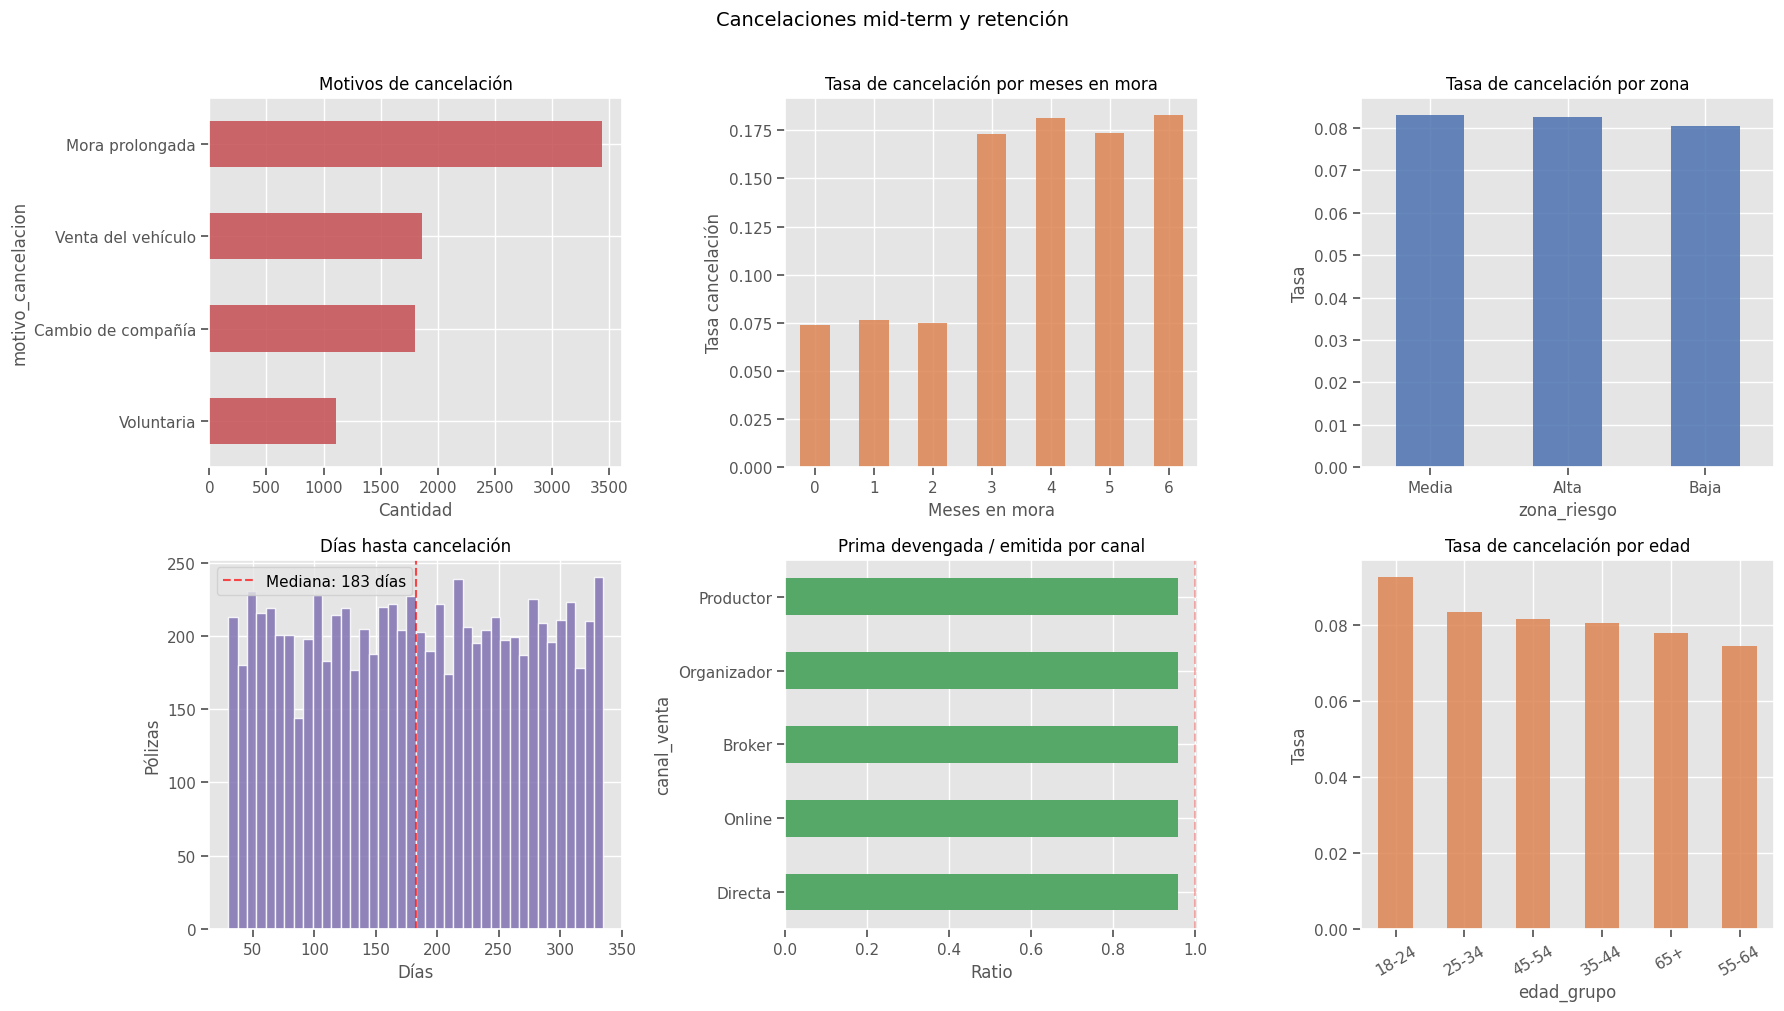

In [27]:

canceladas = df_polizas[df_polizas['cancelada'] == True].copy()
vigentes = df_polizas[df_polizas['cancelada'] == False]
print(f'Pólizas canceladas: {len(canceladas)} ({len(canceladas)/len(df_polizas)*100:.1f}%)')
print(f'Pólizas vigentes:   {len(vigentes)} ({len(vigentes)/len(df_polizas)*100:.1f}%)')

# Prima devengada: proporción del año efectivamente cubierto
df_polizas['dias_vigencia_real'] = np.where(
    df_polizas['cancelada'],
    (df_polizas['fecha_cancelacion'] - df_polizas['fecha_inicio_vigencia']).dt.days,
    365
)
df_polizas['prima_devengada'] = df_polizas['prima'] * df_polizas['dias_vigencia_real'] / 365

prima_emitida = df_polizas['prima'].sum()
prima_devengada = df_polizas['prima_devengada'].sum()
print(f'\nPrima emitida total:   ARS {prima_emitida:,.0f}')
print(f'Prima devengada total: ARS {prima_devengada:,.0f}')
print(f'Pérdida por cancelación: ARS {prima_emitida - prima_devengada:,.0f} ({(1 - prima_devengada/prima_emitida)*100:.2f}%)')

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1. Motivo de cancelación
canceladas['motivo_cancelacion'].value_counts().sort_values().plot(
    kind='barh', ax=axes[0, 0], color='#c44e52', alpha=0.85)
axes[0, 0].set_title('Motivos de cancelación'); axes[0, 0].set_xlabel('Cantidad')

# 2. Tasa de cancelación por mora
tasa_cancel_mora = df_polizas.groupby('meses_en_mora')['cancelada'].mean()
tasa_cancel_mora.plot(kind='bar', ax=axes[0, 1], color='#dd8452', alpha=0.85)
axes[0, 1].set_title('Tasa de cancelación por meses en mora')
axes[0, 1].set_xlabel('Meses en mora'); axes[0, 1].set_ylabel('Tasa cancelación')
axes[0, 1].tick_params(axis='x', rotation=0)

# 3. Tasa de cancelación por zona
tasa_cancel_zona = df_polizas.groupby('zona_riesgo')['cancelada'].mean().sort_values(ascending=False)
tasa_cancel_zona.plot(kind='bar', ax=axes[0, 2], color='#4c72b0', alpha=0.85)
axes[0, 2].set_title('Tasa de cancelación por zona')
axes[0, 2].set_ylabel('Tasa'); axes[0, 2].tick_params(axis='x', rotation=0)

# 4. Distribución de días hasta cancelación
if 'fecha_cancelacion' in canceladas.columns:
    dias_cancel = (canceladas['fecha_cancelacion'] - canceladas['fecha_inicio_vigencia']).dt.days
    axes[1, 0].hist(dias_cancel.dropna(), bins=40, color='#8172b3', alpha=0.85, edgecolor='white')
    axes[1, 0].set_title('Días hasta cancelación'); axes[1, 0].set_xlabel('Días')
    axes[1, 0].set_ylabel('Pólizas')
    axes[1, 0].axvline(dias_cancel.median(), color='red', linestyle='--', alpha=0.7,
                       label=f'Mediana: {dias_cancel.median():.0f} días')
    axes[1, 0].legend()

# 5. Prima devengada / emitida por canal
dev_canal = (df_polizas.groupby('canal_venta')
             .agg(emitida=('prima','sum'), devengada=('prima_devengada','sum')))
dev_canal['ratio'] = dev_canal['devengada'] / dev_canal['emitida']
dev_canal['ratio'].sort_values().plot(kind='barh', ax=axes[1, 1], color='#55a868')
axes[1, 1].set_title('Prima devengada / emitida por canal')
axes[1, 1].set_xlabel('Ratio'); axes[1, 1].axvline(1.0, color='red', linestyle='--', alpha=0.3)

# 6. Tasa de cancelación por grupo de edad
if 'edad_grupo' not in df_polizas.columns:
    df_polizas['edad_grupo'] = pd.cut(
        df_polizas['edad_asegurado'], bins=[17,24,34,44,54,64,100],
        labels=['18-24','25-34','35-44','45-54','55-64','65+'])
tasa_cancel_edad = df_polizas.groupby('edad_grupo', observed=True)['cancelada'].mean().sort_values(ascending=False)
tasa_cancel_edad.plot(kind='bar', ax=axes[1, 2], color='#dd8452', alpha=0.85)
axes[1, 2].set_title('Tasa de cancelación por edad')
axes[1, 2].set_ylabel('Tasa'); axes[1, 2].tick_params(axis='x', rotation=30)

plt.suptitle('Cancelaciones mid-term y retención', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()


## 16) Factores demográficos y frecuencia

En esta versión, **estado civil y ocupación afectan la frecuencia de siniestros**:
- Soltero + edad < 25 → +18% de frecuencia.
- Jubilado → -15% de frecuencia.
- Divorciado + edad < 35 → +8% de frecuencia.

Se analiza si estos efectos son visibles en los datos generados.

,polizas,frecuencia,lr
perfil_riesgo,,,
Jubilado,8171,0.13,1.43
Otros,88705,0.15,1.68
Soltero <25,3124,0.17,1.59


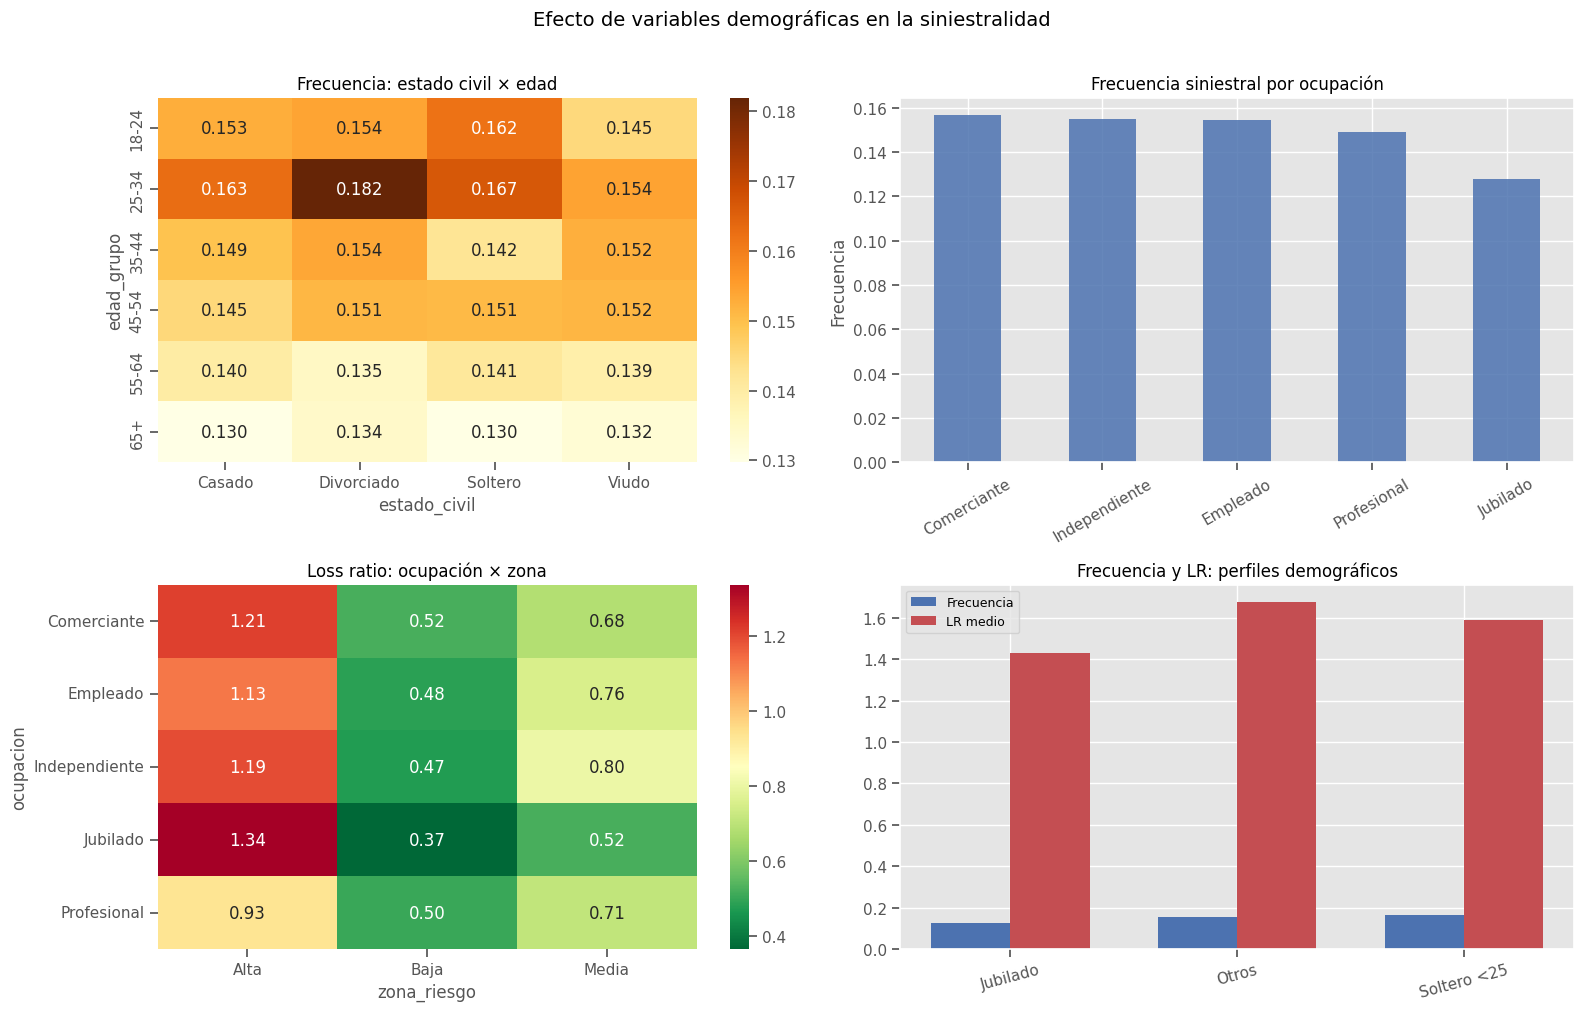

In [28]:

# Prepare segmentation
df_lr_demo = df_lr.copy()
for _col in ['estado_civil', 'ocupacion']:
    if _col not in df_lr_demo.columns:
        df_lr_demo = df_lr_demo.merge(df_polizas[['id_poliza', _col]], on='id_poliza', how='left')

if 'tuvo_siniestro' not in df_lr_demo.columns:
    conteo_sin = df_siniestros.groupby('id_poliza').size().rename('cant_sin')
    df_lr_demo = df_lr_demo.merge(conteo_sin, on='id_poliza', how='left')
    df_lr_demo['cant_sin'] = df_lr_demo['cant_sin'].fillna(0)
    df_lr_demo['tuvo_siniestro'] = df_lr_demo['cant_sin'] > 0

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. Frecuencia por estado civil × edad_grupo
freq_ec_edad = (df_lr_demo.groupby(['edad_grupo', 'estado_civil'], observed=True)['tuvo_siniestro']
                .mean().unstack())
sns.heatmap(freq_ec_edad, annot=True, fmt='.3f', cmap='YlOrBr', ax=axes[0, 0])
axes[0, 0].set_title('Frecuencia: estado civil × edad')

# 2. Frecuencia por ocupación
freq_ocup = df_lr_demo.groupby('ocupacion', observed=True)['tuvo_siniestro'].mean().sort_values(ascending=False)
freq_ocup.plot(kind='bar', ax=axes[0, 1], color='#4c72b0', alpha=0.85)
axes[0, 1].set_title('Frecuencia siniestral por ocupación')
axes[0, 1].set_ylabel('Frecuencia'); axes[0, 1].tick_params(axis='x', rotation=30)
axes[0, 1].set_xlabel('')

# 3. LR: ocupación × zona
if 'zona_riesgo' in df_lr_demo.columns:
    hm_ocup_zona = (df_lr_demo.groupby(['ocupacion', 'zona_riesgo'], observed=True)
                    .apply(lambda x: x['siniestros_incurridos'].sum() / x['prima'].sum() if x['prima'].sum() > 0 else np.nan)
                    .unstack())
    sns.heatmap(hm_ocup_zona, annot=True, fmt='.2f', cmap='RdYlGn_r', ax=axes[1, 0])
    axes[1, 0].set_title('Loss ratio: ocupación × zona')

# 4. Focus: Soltero joven vs resto
df_lr_demo['perfil_riesgo'] = 'Otros'
soltero_joven = (df_lr_demo['estado_civil'] == 'Soltero') & (df_lr_demo['edad_asegurado'] < 25)
jubilado = df_lr_demo['ocupacion'] == 'Jubilado'
df_lr_demo.loc[soltero_joven, 'perfil_riesgo'] = 'Soltero <25'
df_lr_demo.loc[jubilado, 'perfil_riesgo'] = 'Jubilado'

perfil_stats = (df_lr_demo.groupby('perfil_riesgo')
                .agg(polizas=('id_poliza','count'),
                     frecuencia=('tuvo_siniestro','mean'),
                     lr=('loss_ratio_poliza','mean')))
display(perfil_stats)

x = np.arange(len(perfil_stats))
w = 0.35
axes[1, 1].bar(x - w/2, perfil_stats['frecuencia'], w, label='Frecuencia', color='#4c72b0')
axes[1, 1].bar(x + w/2, perfil_stats['lr'], w, label='LR medio', color='#c44e52')
axes[1, 1].set_xticks(x); axes[1, 1].set_xticklabels(perfil_stats.index, rotation=15)
axes[1, 1].set_title('Frecuencia y LR: perfiles demográficos')
axes[1, 1].legend(fontsize=9)

plt.suptitle('Efecto de variables demográficas en la siniestralidad', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()


## 17) Cadenas de renovación y análisis de cohortes

Cada póliza pertenece a un **id_cliente**, y dentro de cada cliente las pólizas se encadenan con `numero_renovacion` = 0, 1, 2, 3. Esto permite análisis de **cohortes**: ¿mejora o empeora la rentabilidad con cada renovación? ¿Los clientes que renuevan más veces tienen mejor perfil?

Se analiza la evolución del LR, frecuencia, prima y cancelaciones a lo largo de las renovaciones.

,loss_ratio,frecuencia,prima_media,polizas
numero_renovacion,,,,
0,0.77,0.15,"647,457.48","52,334.00"
1,0.86,0.15,"790,011.06","28,808.00"
2,0.74,0.15,"983,422.10","14,108.00"
3,0.66,0.16,"1,183,671.76","4,750.00"


,loss_ratio,frecuencia,polizas
grupo_lealtad,,,
Solo 1 período,0.94,0.15,"23,526.00"
2 períodos,0.82,0.15,"29,400.00"
3+ períodos,0.71,0.15,"47,074.00"


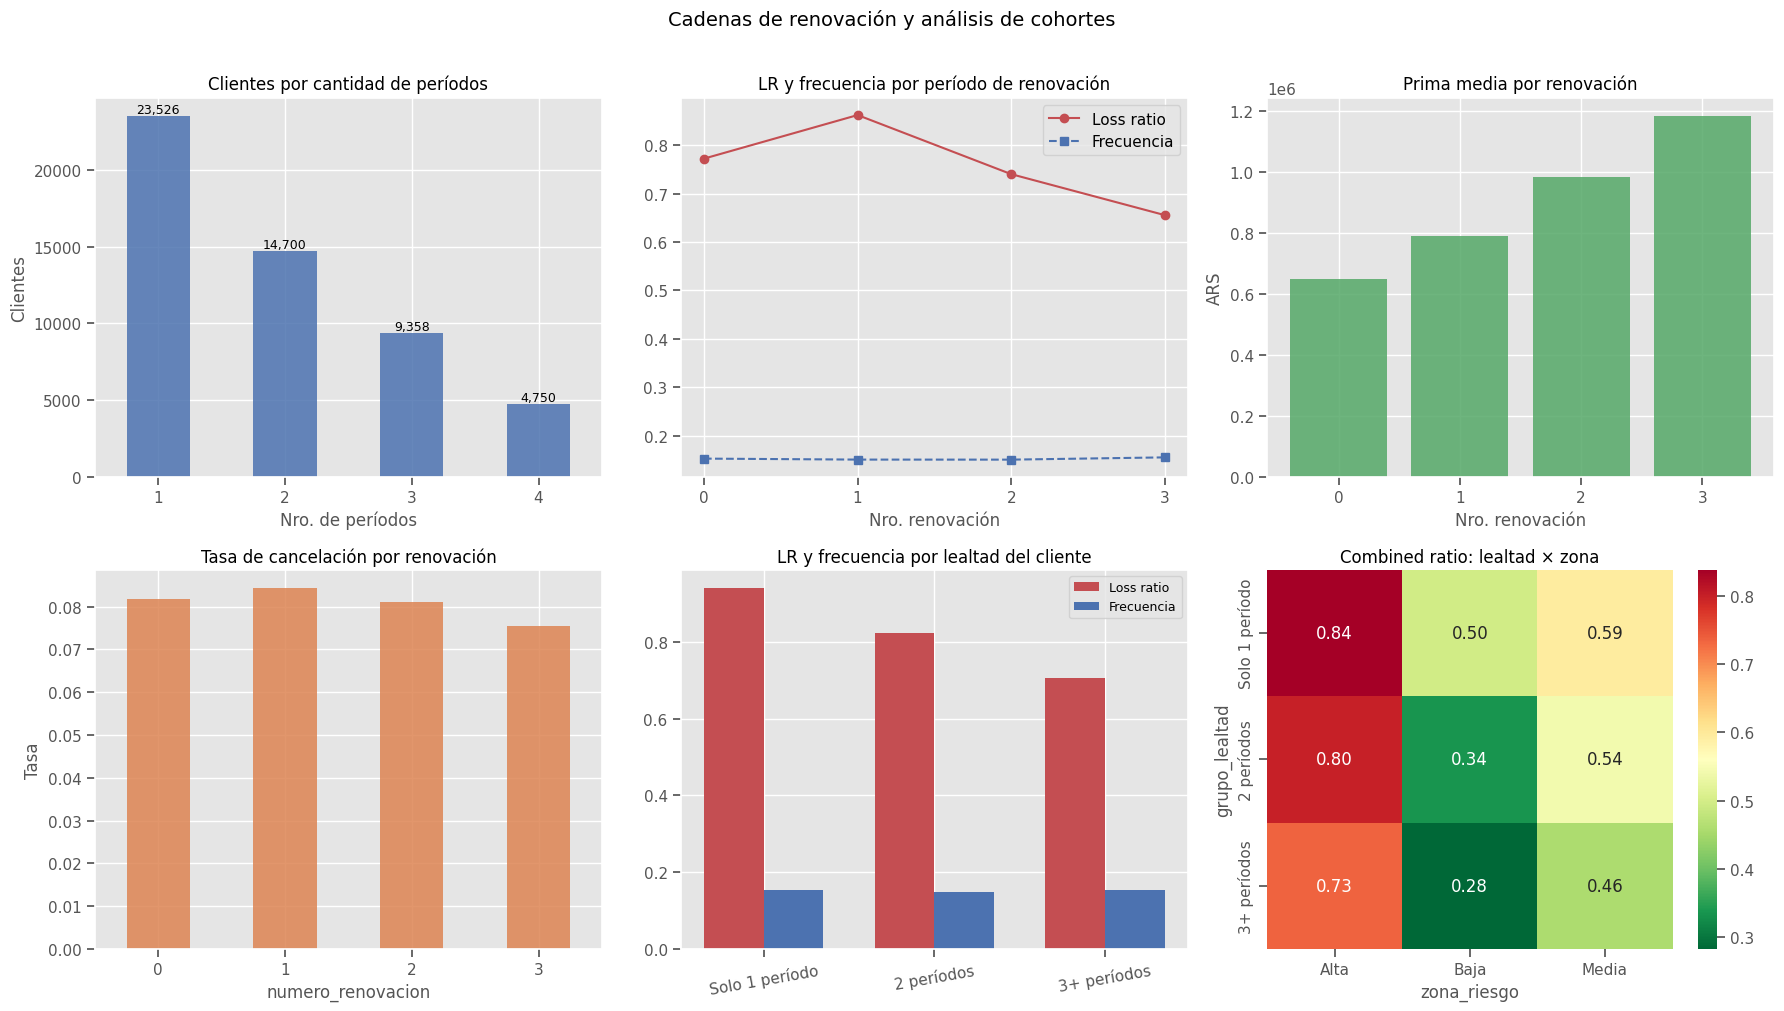

In [29]:

# Enrich df_lr with renewal chain info
for _col in ['id_cliente', 'numero_renovacion', 'cancelada']:
    if _col not in df_lr.columns:
        df_lr = df_lr.merge(df_polizas[['id_poliza', _col]], on='id_poliza', how='left')

# Períodos por cliente
periodos_cliente = df_polizas.groupby('id_cliente').size().rename('periodos_totales')
df_lr = df_lr.merge(periodos_cliente, on='id_cliente', how='left')

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1. Distribución de clientes por cantidad de períodos
periodos_cliente.value_counts().sort_index().plot(
    kind='bar', ax=axes[0, 0], color='#4c72b0', alpha=0.85)
axes[0, 0].set_title('Clientes por cantidad de períodos')
axes[0, 0].set_xlabel('Nro. de períodos'); axes[0, 0].set_ylabel('Clientes')
axes[0, 0].tick_params(axis='x', rotation=0)
for p in axes[0, 0].patches:
    axes[0, 0].annotate(f'{int(p.get_height()):,}',
                        (p.get_x() + p.get_width()/2, p.get_height()),
                        ha='center', va='bottom', fontsize=9)

# 2. LR por número de renovación
lr_por_renov = (df_lr.groupby('numero_renovacion')
                .apply(lambda x: pd.Series({
                    'loss_ratio': x['siniestros_incurridos'].sum() / x['prima'].sum() if x['prima'].sum() > 0 else np.nan,
                    'frecuencia': x['tuvo_siniestro'].mean(),
                    'prima_media': x['prima'].mean(),
                    'polizas': len(x),
                })))
display(lr_por_renov)

axes[0, 1].plot(lr_por_renov.index, lr_por_renov['loss_ratio'], 'o-', color='#c44e52', label='Loss ratio')
axes[0, 1].plot(lr_por_renov.index, lr_por_renov['frecuencia'], 's--', color='#4c72b0', label='Frecuencia')
axes[0, 1].set_title('LR y frecuencia por período de renovación')
axes[0, 1].set_xlabel('Nro. renovación'); axes[0, 1].legend()
axes[0, 1].set_xticks(lr_por_renov.index)

# 3. Prima media por renovación
axes[0, 2].bar(lr_por_renov.index, lr_por_renov['prima_media'], color='#55a868', alpha=0.85)
axes[0, 2].set_title('Prima media por renovación')
axes[0, 2].set_xlabel('Nro. renovación'); axes[0, 2].set_ylabel('ARS')
axes[0, 2].set_xticks(lr_por_renov.index)

# 4. Tasa de cancelación por renovación
if 'cancelada' in df_lr.columns:
    cancel_renov = df_lr.groupby('numero_renovacion')['cancelada'].mean()
    cancel_renov.plot(kind='bar', ax=axes[1, 0], color='#dd8452', alpha=0.85)
    axes[1, 0].set_title('Tasa de cancelación por renovación')
    axes[1, 0].set_ylabel('Tasa'); axes[1, 0].tick_params(axis='x', rotation=0)

# 5. LR por "lealtad" del cliente (1 período vs 2+ vs 3+)
df_lr['grupo_lealtad'] = pd.cut(df_lr['periodos_totales'],
                                bins=[0, 1, 2, 10],
                                labels=['Solo 1 período', '2 períodos', '3+ períodos'])
lr_lealtad = (df_lr.groupby('grupo_lealtad', observed=True)
              .apply(lambda x: pd.Series({
                  'loss_ratio': x['siniestros_incurridos'].sum() / x['prima'].sum(),
                  'frecuencia': x['tuvo_siniestro'].mean(),
                  'polizas': len(x)
              })))
display(lr_lealtad)

x = np.arange(len(lr_lealtad))
w = 0.35
axes[1, 1].bar(x - w/2, lr_lealtad['loss_ratio'], w, label='Loss ratio', color='#c44e52')
axes[1, 1].bar(x + w/2, lr_lealtad['frecuencia'], w, label='Frecuencia', color='#4c72b0')
axes[1, 1].set_xticks(x); axes[1, 1].set_xticklabels(lr_lealtad.index, rotation=10)
axes[1, 1].set_title('LR y frecuencia por lealtad del cliente')
axes[1, 1].legend(fontsize=9)

# 6. Heatmap: grupo_lealtad × zona → combined ratio
if 'gastos_totales' in df_lr.columns:
    hm_lealtad = (df_lr.groupby(['grupo_lealtad', 'zona_riesgo'], observed=True)
                  .apply(lambda x: (x['pagos_totales'].sum() + x['gastos_totales'].sum()) / x['prima'].sum()
                         if x['prima'].sum() > 0 else np.nan)
                  .unstack())
    sns.heatmap(hm_lealtad, annot=True, fmt='.2f', cmap='RdYlGn_r', ax=axes[1, 2])
    axes[1, 2].set_title('Combined ratio: lealtad × zona')
else:
    axes[1, 2].set_visible(False)

plt.suptitle('Cadenas de renovación y análisis de cohortes', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()


## 18) Resumen ejecutivo de métricas

Panel resumen con las **métricas clave de la cartera** en un solo lugar, pensado para visualización rápida en contexto de demo a aseguradoras.

          RESUMEN EJECUTIVO DE CARTERA

Cartera:     100,000 pólizas  |      52,334 clientes  |      16,757 siniestros
Prima total emitida: ARS       76,139,238,219
Prima devengada:     ARS       72,980,780,388

Loss ratio (reclamado):   78.46%
Loss ratio (pagado):      49.20%
Expense ratio:             4.68%
Combined ratio:           53.88%

Frecuencia siniestral:    15.21%
Tasa de rechazo:           7.45%
Tasa de cancelación:       8.21%

Reservas vigentes:  ARS       64,064,886,454
Pagos realizados:   ARS       37,463,258,319
Gastos liquidación: ARS        3,559,999,129


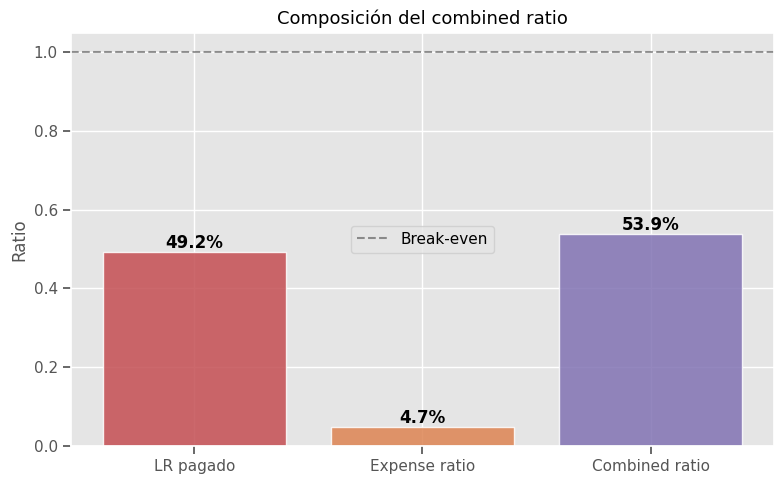

In [30]:

print('=' * 70)
print('          RESUMEN EJECUTIVO DE CARTERA')
print('=' * 70)

n_pol = len(df_polizas)
n_sin = len(df_siniestros)
n_cli = df_polizas['id_cliente'].nunique() if 'id_cliente' in df_polizas.columns else n_pol

prima_total = df_polizas['prima'].sum()
pagos_total = df_siniestros['monto_pagado'].sum()
gastos_total = df_siniestros['gasto_liquidacion'].sum()
reservas_total = df_siniestros['monto_reservado'].sum()

lr_rec = df_siniestros['monto_reclamado'].sum() / prima_total
lr_pag = pagos_total / prima_total
exp_r = gastos_total / prima_total
comb_r = lr_pag + exp_r

frecuencia = df_siniestros['id_poliza'].nunique() / n_pol
tasa_rechazo = (df_siniestros['estado_siniestro'] == 'Rechazado').mean()
tasa_cancel = df_polizas['cancelada'].mean() if 'cancelada' in df_polizas.columns else 0

print(f'\nCartera:  {n_pol:>10,} pólizas  |  {n_cli:>10,} clientes  |  {n_sin:>10,} siniestros')
print(f'Prima total emitida: ARS {prima_total:>20,.0f}')
print(f'Prima devengada:     ARS {df_polizas["prima_devengada"].sum() if "prima_devengada" in df_polizas.columns else prima_total:>20,.0f}')
print()
print(f'Loss ratio (reclamado): {lr_rec:>8.2%}')
print(f'Loss ratio (pagado):    {lr_pag:>8.2%}')
print(f'Expense ratio:          {exp_r:>8.2%}')
print(f'Combined ratio:         {comb_r:>8.2%}')
print()
print(f'Frecuencia siniestral:  {frecuencia:>8.2%}')
print(f'Tasa de rechazo:        {tasa_rechazo:>8.2%}')
print(f'Tasa de cancelación:    {tasa_cancel:>8.2%}')
print()
print(f'Reservas vigentes:  ARS {reservas_total:>20,.0f}')
print(f'Pagos realizados:   ARS {pagos_total:>20,.0f}')
print(f'Gastos liquidación: ARS {gastos_total:>20,.0f}')
print('=' * 70)

# Quick visual: waterfall-style combined ratio
fig, ax = plt.subplots(figsize=(8, 5))
componentes = ['LR pagado', 'Expense ratio', 'Combined ratio']
valores = [lr_pag, exp_r, comb_r]
colores = ['#c44e52', '#dd8452', '#8172b3']
bars = ax.bar(componentes, valores, color=colores, alpha=0.85, edgecolor='white')
ax.axhline(1.0, color='black', linestyle='--', alpha=0.4, label='Break-even')
for bar, val in zip(bars, valores):
    ax.annotate(f'{val:.1%}', (bar.get_x() + bar.get_width()/2, bar.get_height()),
                ha='center', va='bottom', fontsize=12, fontweight='bold')
ax.set_title('Composición del combined ratio', fontsize=13)
ax.set_ylabel('Ratio'); ax.legend()
plt.tight_layout()
plt.show()
